In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression,Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,  classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, Ridge

## Before EDA

In [2]:
df = pd.read_csv('Fifa.csv')
df.columns = [c.strip().lower() for c in df.columns]

print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows   : 19667
Columns: 9


,name,country,position,age,overall_rating,future potential,team,value per m$,total_stats score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


### Null Values and Duplicates

In [3]:
# Check number of duplicate rows in the dataset
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [4]:
print("Number of Null rows:", df.isnull().sum().sum())

Number of Null rows: 0


### Feature Types

In [5]:
numerical   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical features  :', numerical)
print('Categorical features:', categorical)
print()
print(df.dtypes)

Numerical features  : ['age', 'overall_rating', 'future potential', 'value per m$', 'total_stats score']
Categorical features: ['name', 'country', 'position', 'team']

name                  object
country               object
position              object
age                    int64
overall_rating         int64
future potential       int64
team                  object
value per m$         float64
total_stats score      int64
dtype: object


### The Discribtion of Features

In [6]:
df.describe()

,age,overall_rating,future potential,value per m$,total_stats score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


### **Relationship with numerical features**

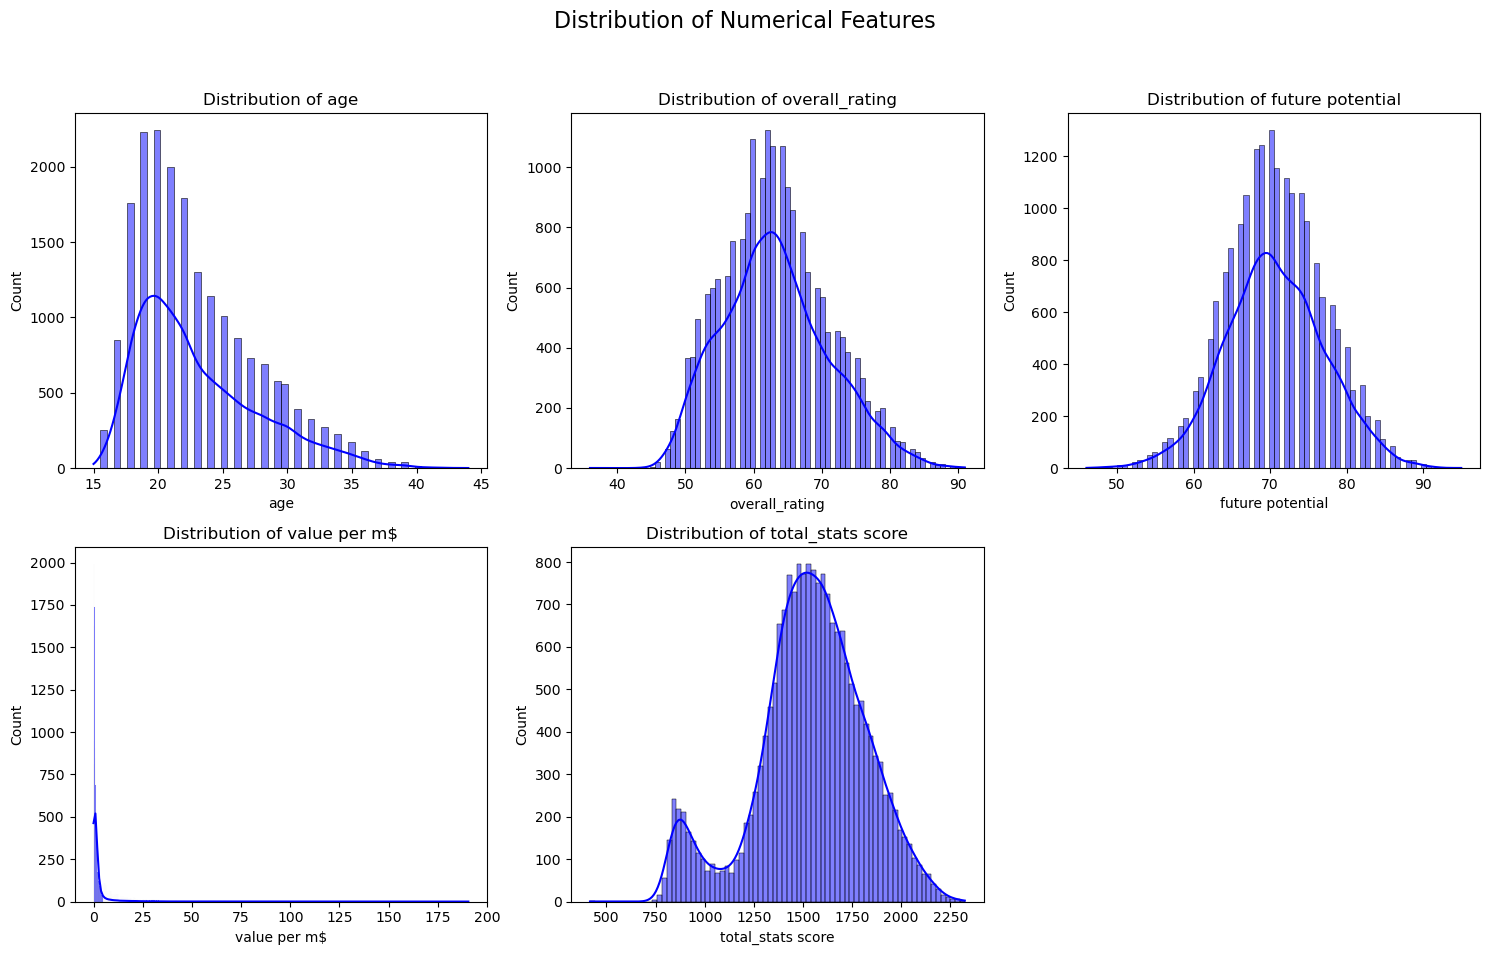

In [7]:
num_features = ['age', 'overall_rating', 'future potential', 'value per m$', 'total_stats score']
cat_features = ['country', 'position', 'team']
plt.figure(figsize=(15, 10))
plt.suptitle('Distribution of Numerical Features', fontsize=16)

for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

### In Value per M there are many players that have value between 0 and 2 and in dscribe method we know that the Q3 =1,6M and also that there are players that have a big value such 190.500000	and it is not outlier because truely that truely have this big value

### **Relationship with Categorical Features**

# 1- Relationship between 'position' and 'value per m$

C:\Users\user\AppData\Local\Temp\ipykernel_14076\3476450980.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='position', y='value per m$', data=df, palette='viridis')


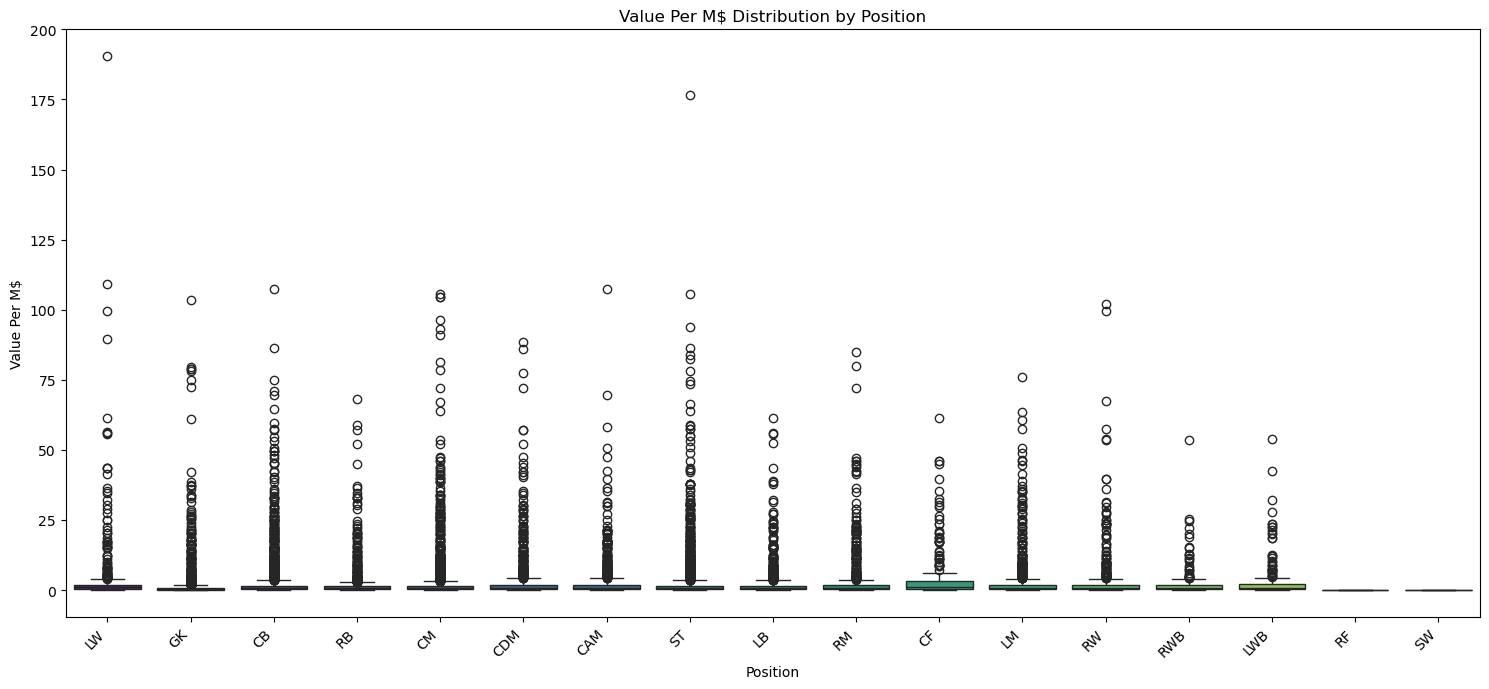

In [8]:
plt.figure(figsize=(15, 7))
sns.boxplot(x='position', y='value per m$', data=df, palette='viridis')
plt.title('Value Per M$ Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Value Per M$')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2- Relationship between 'country' and 'value per m$'

C:\Users\user\AppData\Local\Temp\ipykernel_14076\333905569.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='country', y='value per m$', data=df_top_countries, palette='magma')


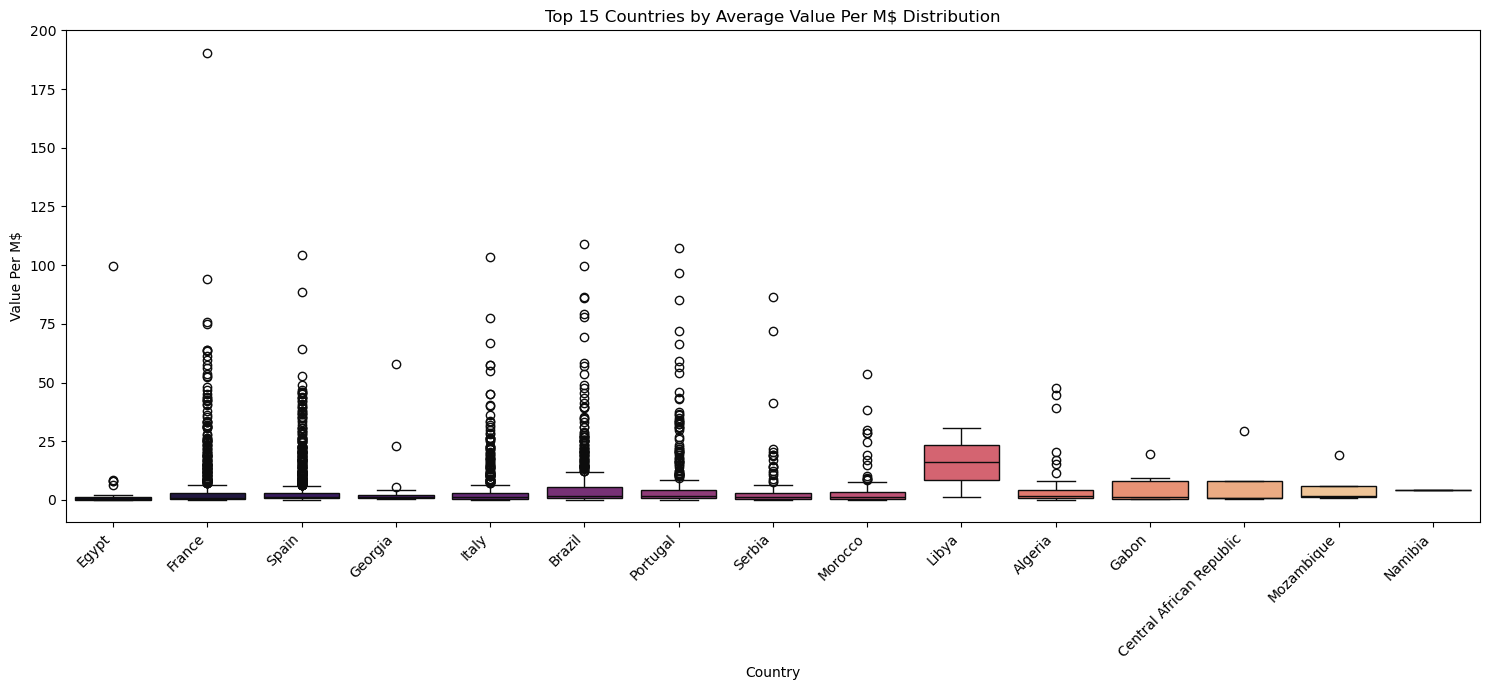

In [9]:
top_countries = df.groupby('country')['value per m$'].mean().nlargest(15).index
df_top_countries = df[df['country'].isin(top_countries)]

plt.figure(figsize=(15, 7))
sns.boxplot(x='country', y='value per m$', data=df_top_countries, palette='magma')
plt.title('Top 15 Countries by Average Value Per M$ Distribution')
plt.xlabel('Country')
plt.ylabel('Value Per M$')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Task 1: EDA

### 1 - Check missing values

In [10]:
missing_values = df.isnull().sum()

print(missing_values)

print("Total Missing Values:", df.isnull().sum().sum())

name                 0
country              0
position             0
age                  0
overall_rating       0
future potential     0
team                 0
value per m$         0
total_stats score    0
dtype: int64
Total Missing Values: 0


### 2- Distribution of Value Per M$

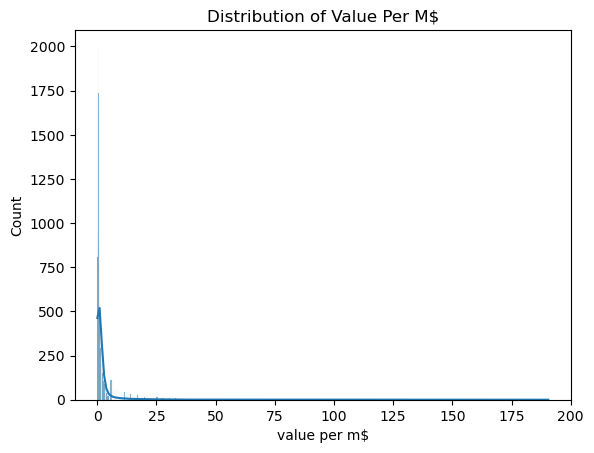

Skewness: 7.983215201865151


In [11]:
sns.histplot(df['value per m$'], kde=True)
plt.title("Distribution of Value Per M$")
plt.show()

# Skewness
skewness = df['value per m$'].skew()
print("Skewness:", skewness)
# it is not normal, there is right skewe

### 3- Correlation with Value Per M

value per m$         1.000000
overall_rating       0.560648
future potential     0.500964
total_stats score    0.385062
age                  0.142276
Name: value per m$, dtype: float64


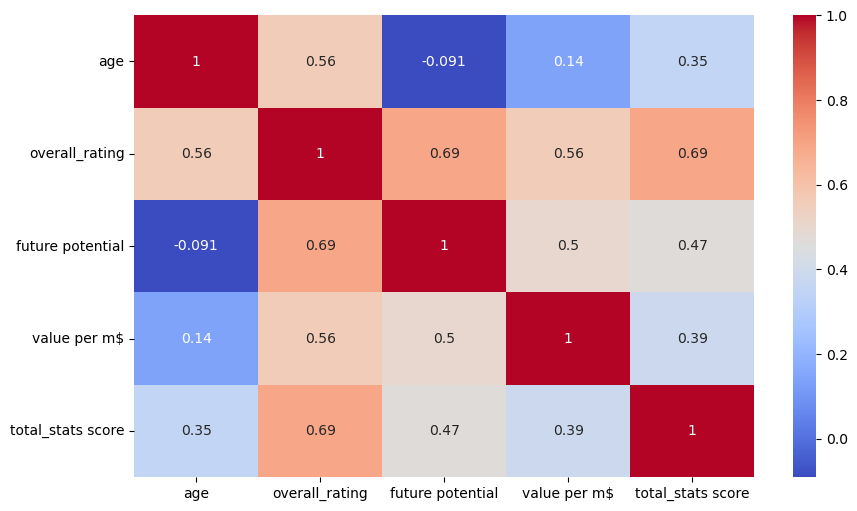

In [12]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Correlation with target
corr_target = corr['value per m$'].sort_values(ascending=False)

print(corr_target)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

1. overall_rating
2. future potential
3. total score
4. age

### 4- Average Rating per Position

In [13]:
avg_rating = df.groupby('position')['overall_rating'].mean()
print(avg_rating)

position
CAM    63.679709
CB     63.544448
CDM    64.234168
CF     66.042857
CM     62.511767
GK     60.987288
LB     63.276794
LM     64.172009
LW     64.345979
LWB    64.043333
RB     62.863636
RF     75.000000
RM     63.907731
RW     63.718529
RWB    64.063973
ST     63.087505
SW     75.000000
Name: overall_rating, dtype: float64


### Average Overall Rating per Position Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_14076\2996716877.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.index, y=avg_rating.values, palette='viridis')


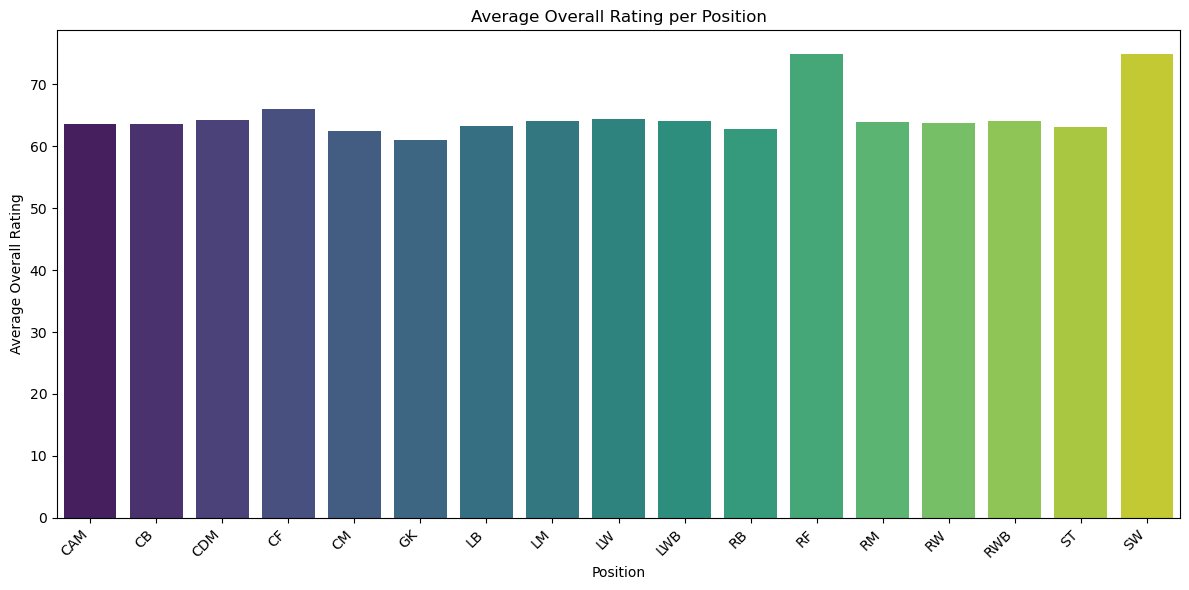

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette='viridis')
plt.title('Average Overall Rating per Position')
plt.xlabel('Position')
plt.ylabel('Average Overall Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Task 2: Data Preprocessing


In [15]:
df = df[df['value per m$'] > 0]


### 1- Split Data

In [16]:
# Split dataset into training and testing sets
X = df.drop('value per m$', axis=1)
y = df['value per m$']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Check the shape of training and testing sets
Train=pd.concat([X_train, y_train], axis=1)
Test=pd.concat([X_test, y_test], axis=1)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15469, 8)
X_test shape: (3868, 8)
y_train shape: (15469,)
y_test shape: (3868,)


In [17]:
Train

,name,country,position,age,overall_rating,future potential,team,total_stats score,value per m$
16518,Felix Kekoh,Cameroon,RM,19,55,69,Admira,1403,0.300
9507,Pharrell Willis,England,LM,19,53,64,Middlesbrough,1311,0.200
8701,Alessandro Seghetti,Italy,ST,18,56,69,Perugia,1377,0.325
1673,Georginio Wijnaldum,Netherlands,CDM,31,80,80,Roma,2186,17.500
7042,Adrien Tameze,France,CDM,28,75,75,Hellas Verona,2058,5.500
...,...,...,...,...,...,...,...,...,...
11563,Emiliano Brienza,Canada,CAM,20,51,68,Vancouver Whitecaps,1285,0.150
12244,Anton Eriksson,Sweden,CB,22,64,74,Norrköping,1449,1.200
5500,André Anderson Pomilio Lima,Italy,ST,21,64,74,Lazio,1534,1.300
882,Omar Richards,England,LWB,24,72,77,Nottingham Forest,1758,3.300


In [18]:
df["team"].nunique()

948

In [19]:
df["country"].nunique()

163

Deleting the country , Name, Team does not effect of value or the rating or the score
#### country such as Mohamed Salah have a market value upper than 100 Million and its Egyptian and the AVG of Egyptian players between 0 and 5 million and also in any team have a players have a players have a big value and small value so it does not depend on team and also the teams have a 10009 team it must be canceled because of curse of dimensionality at one hot encoder it will be make 1009 columns


In [20]:
Train=Train.drop(columns=['name','country', 'team'])
Test=Test.drop(columns=['name','country', 'team'])

In [21]:
Train

,position,age,overall_rating,future potential,total_stats score,value per m$
16518,RM,19,55,69,1403,0.300
9507,LM,19,53,64,1311,0.200
8701,ST,18,56,69,1377,0.325
1673,CDM,31,80,80,2186,17.500
7042,CDM,28,75,75,2058,5.500
...,...,...,...,...,...,...
11563,CAM,20,51,68,1285,0.150
12244,CB,22,64,74,1449,1.200
5500,ST,21,64,74,1534,1.300
882,LWB,24,72,77,1758,3.300


### 2- Encode categorical columns

In [22]:
onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_data_train = onehot.fit_transform(Train[['position']])
encoded_df_train = pd.DataFrame(
    encoded_data_train,
    columns=onehot.get_feature_names_out(['position']),
    index=Train.index
)

Train = pd.concat([Train, encoded_df_train], axis=1)
Train.drop(columns=['position'], inplace=True)

# ---------------------------------------------------------

encoded_data_test = onehot.transform(Test[['position']])
encoded_df_test = pd.DataFrame(
    encoded_data_test,
    columns=onehot.get_feature_names_out(['position']),
    index=Test.index
)

Test = pd.concat([Test, encoded_df_test], axis=1)
Test.drop(columns=['position'], inplace=True)

In [23]:
Train

,age,overall_rating,future potential,total_stats score,value per m$,position_CAM,position_CB,position_CDM,position_CF,position_CM,position_GK,position_LB,position_LM,position_LW,position_LWB,position_RB,position_RM,position_RW,position_RWB,position_ST
16518,19,55,69,1403,0.300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9507,19,53,64,1311,0.200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8701,18,56,69,1377,0.325,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1673,31,80,80,2186,17.500,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7042,28,75,75,2058,5.500,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11563,20,51,68,1285,0.150,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12244,22,64,74,1449,1.200,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5500,21,64,74,1534,1.300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
882,24,72,77,1758,3.300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [24]:
Test

,age,overall_rating,future potential,total_stats score,value per m$,position_CAM,position_CB,position_CDM,position_CF,position_CM,position_GK,position_LB,position_LM,position_LW,position_LWB,position_RB,position_RM,position_RW,position_RWB,position_ST
15449,20,59,74,1353,0.550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6429,22,79,79,2016,19.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2608,19,52,69,815,0.180,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1051,24,77,82,2076,14.500,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2301,30,66,66,1115,0.575,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15603,20,67,77,1417,2.100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5746,22,69,77,1660,3.200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3986,18,61,79,1661,0.775,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12822,17,54,70,1393,0.250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### 3- Scale numerical features

In [25]:
Train_raw = Train.copy()
Test_raw = Test.copy()
num_features = ['age', 'overall_rating', 'future potential', 'value per m$', 'total_stats score']
cat_features = ['country', 'position', 'team']
standard_cols = [ 'future potential', 'total_stats score']

Train["age"]=np.log1p(Train["age"])
Test["age"]=np.log1p(Test["age"])

Train["value per m$"]=np.log1p(Train["value per m$"])
Test["value per m$"]=np.log1p(Test["value per m$"])

std_scaler = StandardScaler()
Train[standard_cols] = std_scaler.fit_transform(Train[standard_cols])
Test[standard_cols] = std_scaler.transform(Test[standard_cols])

### 4- Detect and handle outliers

deleting the players that are have not value

In [26]:
Train.describe()

,age,overall_rating,future potential,total_stats score,value per m$,position_CAM,position_CB,position_CDM,position_CF,position_CM,position_GK,position_LB,position_LM,position_LW,position_LWB,position_RB,position_RM,position_RW,position_RWB,position_ST
count,15469.000000,15469.000000,1.546900e+04,1.546900e+04,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000,15469.000000
mean,3.157410,63.172539,-6.710860e-16,3.288827e-16,0.776718,0.056306,0.151917,0.068072,0.014222,0.128515,0.108152,0.055595,0.063029,0.033228,0.015127,0.056823,0.061090,0.036201,0.014739,0.136984
std,0.182840,7.807130,1.000032e+00,1.000032e+00,0.753459,0.230519,0.358952,0.251877,0.118409,0.334673,0.310582,0.229145,0.243023,0.179237,0.122062,0.231512,0.239503,0.186797,0.120511,0.343841
min,2.772589,44.000000,-3.802746e+00,-2.773732e+00,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.995732,58.000000,-7.158492e-01,-5.135317e-01,0.281412,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.135494,63.000000,-9.846980e-02,5.505007e-02,0.530628,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.295837,68.000000,6.732544e-01,6.518843e-01,0.955511,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.806662,91.000000,3.605806e+00,2.717849e+00,5.178971,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Task 3, 5: Logistic Regression Model

### Classifying the rating

In [27]:
low, mid, high = 65, 75, 85

def classify(rating):
    if rating < low: return 'low'
    elif rating < mid: return 'mid'
    elif rating < high: return 'high'
    else: return 'elite'

Train['Performance_Tier'] = Train['overall_rating'].apply(classify)
Test['Performance_Tier'] = Test['overall_rating'].apply(classify)

print(f"Thresholds fixed from Train: {low}, {mid}, {high}")
rating_scaler = StandardScaler()
Train['overall_rating'] = rating_scaler.fit_transform(Train[['overall_rating']])
Test['overall_rating'] = rating_scaler.transform(Test[['overall_rating']])

Thresholds fixed from Train: 65, 75, 85


In [28]:
Train.head()

,age,overall_rating,future potential,total_stats score,value per m$,position_CAM,position_CB,position_CDM,position_CF,position_CM,...,position_LB,position_LM,position_LW,position_LWB,position_RB,position_RM,position_RW,position_RWB,position_ST,Performance_Tier
16518,2.995732,-1.046838,-0.252815,-0.464090,0.262364,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,low
9507,2.995732,-1.303023,-1.024539,-0.788994,0.182322,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,low
8701,2.944439,-0.918746,-0.252815,-0.555910,0.281412,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,low
1673,3.465736,2.155466,1.444979,2.301125,2.917771,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,high
7042,3.367296,1.515005,0.673254,1.849084,1.871802,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,high


### Show how many players fall into each category

Performance_Tier
low      9285
mid      4782
high     1330
elite      72
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_14076\1017786868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts.index, y=train_counts.values, palette=colors, edgecolor='black')


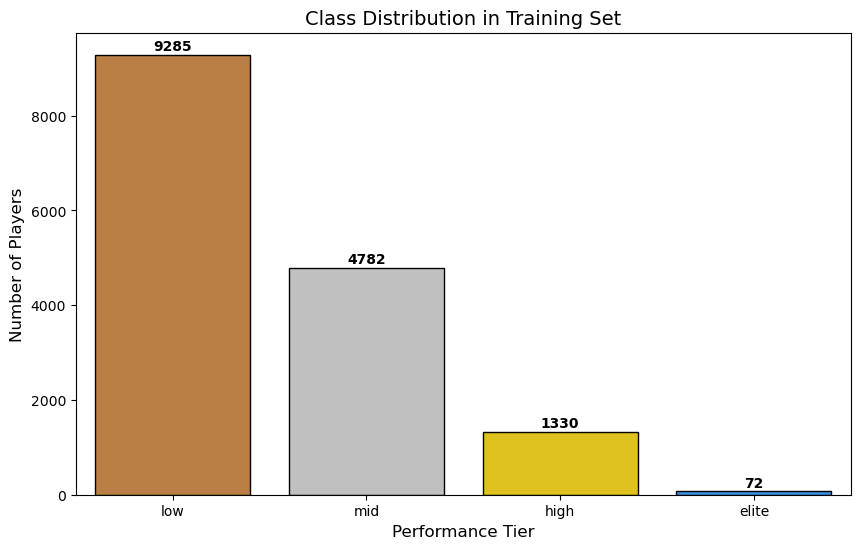

In [29]:
train_counts = Train['Performance_Tier'].value_counts().reindex(['low', 'mid', 'high', 'elite'])
print(train_counts)

plt.figure(figsize=(10, 6))
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#1e90ff']
sns.barplot(x=train_counts.index, y=train_counts.values, palette=colors, edgecolor='black')

for i, v in enumerate(train_counts.values):
    plt.text(i, v + (train_counts.max()*0.01), str(v), ha='center', fontweight='bold')

plt.title('Class Distribution in Training Set', fontsize=14)
plt.xlabel('Performance Tier', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.show()


Performance_Tier
low      2332
mid      1198
high      319
elite      19
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_14076\2458091990.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_counts.index, y=test_counts.values, palette=colors, edgecolor='black')


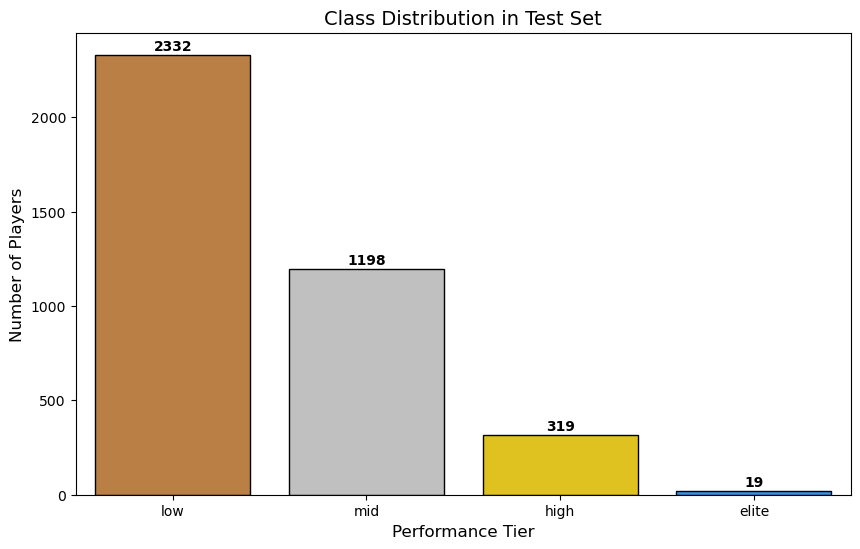

In [30]:
test_counts = Test['Performance_Tier'].value_counts().reindex(['low', 'mid', 'high', 'elite'])
print(test_counts)

plt.figure(figsize=(10, 6))
colors = ['#cd7f32', '#c0c0c0', '#ffd700', '#1e90ff']
sns.barplot(x=test_counts.index, y=test_counts.values, palette=colors, edgecolor='black')

for i, v in enumerate(test_counts.values):
    plt.text(i, v + (test_counts.max()*0.01), str(v), ha='center', fontweight='bold')

plt.title('Class Distribution in Test Set', fontsize=14)
plt.xlabel('Performance Tier', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.show()


 The distribution is balanced because the thresholds were derived from the equal quartiles ($Q1, Q2, Q3$) of the training data.

### Applying the ordinal ecoding by lable encoding to be ready to go to the model

In [31]:
mapping = {'low': 0, 'mid': 1, 'high': 2, 'elite': 3}

Train['Performance_Tier'] = Train['Performance_Tier'].map(mapping)
Test['Performance_Tier'] = Test['Performance_Tier'].map(mapping)

In [32]:
Train.head()

,age,overall_rating,future potential,total_stats score,value per m$,position_CAM,position_CB,position_CDM,position_CF,position_CM,...,position_LB,position_LM,position_LW,position_LWB,position_RB,position_RM,position_RW,position_RWB,position_ST,Performance_Tier
16518,2.995732,-1.046838,-0.252815,-0.464090,0.262364,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
9507,2.995732,-1.303023,-1.024539,-0.788994,0.182322,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
8701,2.944439,-0.918746,-0.252815,-0.555910,0.281412,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1673,3.465736,2.155466,1.444979,2.301125,2.917771,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
7042,3.367296,1.515005,0.673254,1.849084,1.871802,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


### Train the the model

In [33]:
X_train = Train.drop(['overall_rating', 'Performance_Tier'], axis=1)
y_train = Train['Performance_Tier']
X_test = Test.drop(['overall_rating', 'Performance_Tier'], axis=1)
y_test = Test['Performance_Tier']

#### Baseline Model & Confusion Matrix

In [34]:
# Baseline Logistic Regression
baseline_model = LogisticRegression(max_iter=2000)
baseline_model.fit(X_train, y_train)

# Evaluation
y_pred = baseline_model.predict(X_test)
print("Baseline Classification Report:\n")
print(classification_report(y_test, y_pred))
# 'Bronze', 'Silver', 'Gold', 'Elite'

Baseline Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2332
           1       0.95      0.94      0.95      1198
           2       0.94      0.94      0.94       319
           3       0.89      0.42      0.57        19

    accuracy                           0.96      3868
   macro avg       0.94      0.82      0.86      3868
weighted avg       0.96      0.96      0.96      3868



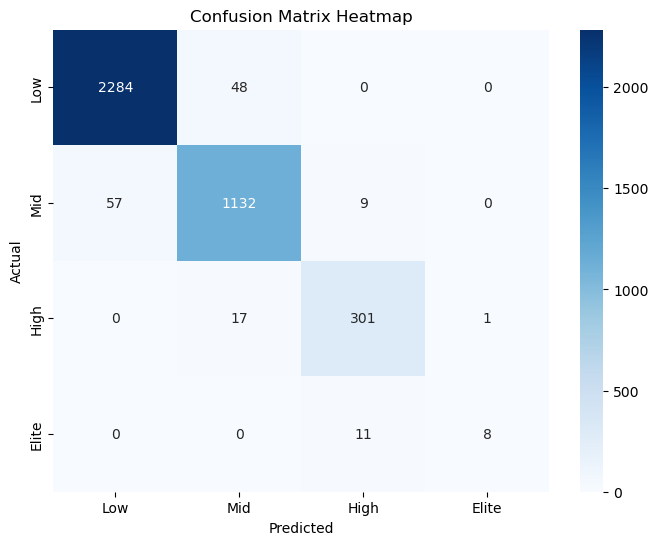

In [35]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Mid', 'High', 'Elite'],
            yticklabels=['Low', 'Mid', 'High', 'Elite'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Regularization Model

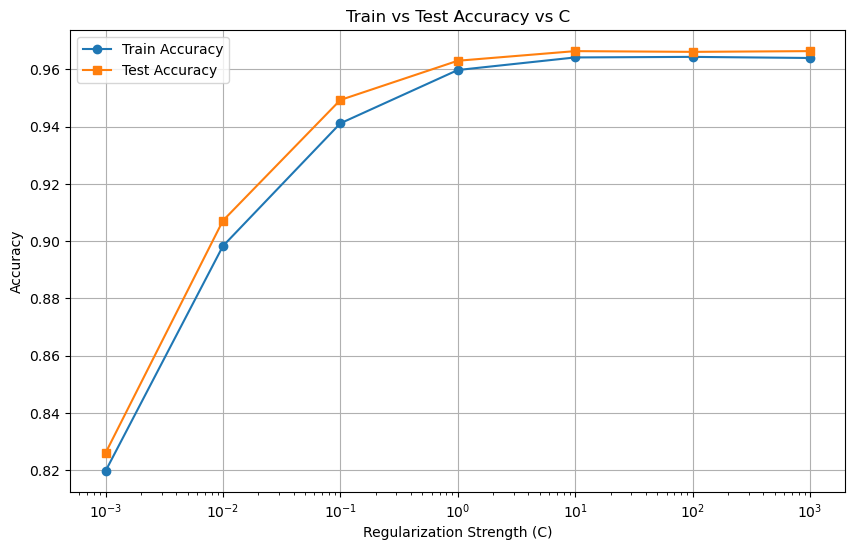

Best C value: 10.0


In [36]:
C_range = np.logspace(-3, 3, 7) # [0.001, 0.01, 0.1, 1, 10, 100, 1000]
train_acc = []
test_acc = []

for c in C_range:
    lr = LogisticRegression(C=c, max_iter=2000)
    lr.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, lr.predict(X_train)))
    test_acc.append(accuracy_score(y_test, lr.predict(X_test)))


# Chart
plt.figure(figsize=(10, 6))
plt.semilogx(C_range, train_acc, label='Train Accuracy', marker='o')
plt.semilogx(C_range, test_acc, label='Test Accuracy', marker='s')
plt.xlabel('Regularization Strength (C)')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy vs C')
plt.legend()
plt.grid(True)
plt.show()

best_c = C_range[np.argmax(test_acc)]
print(f"Best C value: {best_c}")

we can see 1 is the best c, this is the high acc in train and test data

In [37]:
# L1 Regularization (Saga solver)
l1_model = LogisticRegression(penalty='l1', C=best_c, solver='saga', max_iter=5000)
l1_model.fit(X_train, y_train)
l1_score = accuracy_score(y_test, l1_model.predict(X_test))

# L2 Regularization (LBFGS solver)
l2_model = LogisticRegression(penalty='l2', C=best_c, solver='lbfgs', max_iter=5000)
l2_model.fit(X_train, y_train)
l2_score = accuracy_score(y_test, l2_model.predict(X_test))

print(f"L1 (Saga) Test Accuracy: {l1_score:.4f}")
print(f"L2 (LBFGS) Test Accuracy: {l2_score:.4f}")

c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.wa

L1 (Saga) Test Accuracy: 0.9669
L2 (LBFGS) Test Accuracy: 0.9664


L2 (LBFGS) is better.

## Task 4 - Model one : Polynomial regression

###  Prepare Feature Arrays
`PolynomialFeatures` is applied **only to numerical features**,
OHE position columns are kept as-is and re-attached after expansion.


In [38]:
numerical_features = [ 'age', 'overall_rating', 'future potential', 'total_stats score']
ohe_cols  = [c for c in Train.columns if c.startswith('position_')]

X_train_num = Train[numerical_features].values
X_test_num  = Test[numerical_features].values
X_train_ohe = Train[ohe_cols].values
X_test_ohe  = Test[ohe_cols].values
y_train_reg = Train['value per m$']
y_test_reg  = Test['value per m$']

print(f"Numerical features : {numerical_features}")
print(f"OHE position cols  : {len(ohe_cols)} columns")

Numerical features : ['age', 'overall_rating', 'future potential', 'total_stats score']
OHE position cols  : 15 columns


###  Evaluation method

In [39]:
def evaluate_model(y_true_tr, y_pred_tr, y_true_te, y_pred_te):
    print("Train:")
    print("MAE =", mean_absolute_error(y_true_tr, y_pred_tr))
    print("MSE =", mean_squared_error(y_true_tr, y_pred_tr))
    print("RMSE =", np.sqrt(mean_squared_error(y_true_tr, y_pred_tr)))
    print("R2 =", r2_score(y_true_tr, y_pred_tr))

    print("\nTest:")
    print("MAE =", mean_absolute_error(y_true_te, y_pred_te))
    print("MSE =", mean_squared_error(y_true_te, y_pred_te))
    print("RMSE =", np.sqrt(mean_squared_error(y_true_te, y_pred_te)))
    print("R2 =", r2_score(y_true_te, y_pred_te))

###  Baseline — Linear Regression (degree = 1)
Train a standard Linear Regression model and evaluate using MAE, MSE, RMSE, and R².


In [40]:
print("=" * 60)
print("Baseline: Linear Regression  (degree = 1)")
print("=" * 60)

X_tr_base = np.hstack([X_train_num, X_train_ohe])
X_te_base = np.hstack([X_test_num,  X_test_ohe])

lr_base = LinearRegression()
lr_base.fit(X_tr_base, y_train_reg)

baseline_results = evaluate_model(
    y_train_reg, lr_base.predict(X_tr_base),
    y_test_reg,  lr_base.predict(X_te_base)
)

Baseline: Linear Regression  (degree = 1)
Train:
MAE = 0.2296251201823391
MSE = 0.09774728885333461
RMSE = 0.3126456282332037
R2 = 0.8278077366731054

Test:
MAE = 0.22919230802838225
MSE = 0.09650537993574718
RMSE = 0.31065315053246634
R2 = 0.8282887134984264


### 6. Polynomial Regression — Degrees 1 to 4
For each degree, record Train R² and Test R² and the overfitting gap.


In [41]:
print("=" * 60)
print("Polynomial Regression — Degrees 1 to 4")
print("=" * 60)

degrees     = [1, 2, 3, 4, 5, 6, 7, 8]
train_r2s   = []
test_r2s    = []
train_rmses = []
test_rmses  = []

for deg in degrees:
    poly    = PolynomialFeatures(degree=deg, include_bias=False)
    Xtr_p   = poly.fit_transform(X_train_num)   # expand numerical only
    Xte_p   = poly.transform(X_test_num)
    Xtr_all = np.hstack([Xtr_p, X_train_ohe])   # re-attach OHE
    Xte_all = np.hstack([Xte_p, X_test_ohe])

    model = LinearRegression()
    model.fit(Xtr_all, y_train_reg)

    y_tr_pred = model.predict(Xtr_all)
    y_te_pred = model.predict(Xte_all)

    tr_r2   = r2_score(y_train_reg, y_tr_pred)
    te_r2   = r2_score(y_test_reg,  y_te_pred)
    tr_rmse = np.sqrt(mean_squared_error(y_train_reg, y_tr_pred))
    te_rmse = np.sqrt(mean_squared_error(y_test_reg,  y_te_pred))

    train_r2s.append(tr_r2)
    test_r2s.append(te_r2)
    train_rmses.append(tr_rmse)
    test_rmses.append(te_rmse)

    gap = tr_r2 - te_r2
    flag = " overfitting" if gap > 0.05 else "good"
    print(f"\n  Degree {deg}  |  Poly features: {Xtr_p.shape[1]}")
    print(f"    Train  R²={tr_r2:.4f}   RMSE={tr_rmse:.4f}")
    print(f"    Test   R²={te_r2:.4f}   RMSE={te_rmse:.4f}")
    print(f"    Train/Test gap = {gap:.4f}  {flag}")


Polynomial Regression — Degrees 1 to 4

  Degree 1  |  Poly features: 4
    Train  R²=0.8278   RMSE=0.3126
    Test   R²=0.8283   RMSE=0.3107
    Train/Test gap = -0.0005  good

  Degree 2  |  Poly features: 14
    Train  R²=0.9787   RMSE=0.1098
    Test   R²=0.9791   RMSE=0.1083
    Train/Test gap = -0.0004  good

  Degree 3  |  Poly features: 34
    Train  R²=0.9834   RMSE=0.0971
    Test   R²=0.9837   RMSE=0.0958
    Train/Test gap = -0.0003  good

  Degree 4  |  Poly features: 69
    Train  R²=0.9883   RMSE=0.0817
    Test   R²=0.9888   RMSE=0.0793
    Train/Test gap = -0.0005  good

  Degree 5  |  Poly features: 125
    Train  R²=0.9907   RMSE=0.0727
    Test   R²=0.9907   RMSE=0.0723
    Train/Test gap = -0.0000  good

  Degree 6  |  Poly features: 209
    Train  R²=0.9913   RMSE=0.0702
    Test   R²=0.9908   RMSE=0.0718
    Train/Test gap = 0.0005  good

  Degree 7  |  Poly features: 329
    Train  R²=0.9926   RMSE=0.0650
    Test   R²=0.9907   RMSE=0.0723
    Train/Test gap = 0

### 7. Plot — Degree vs. Performance

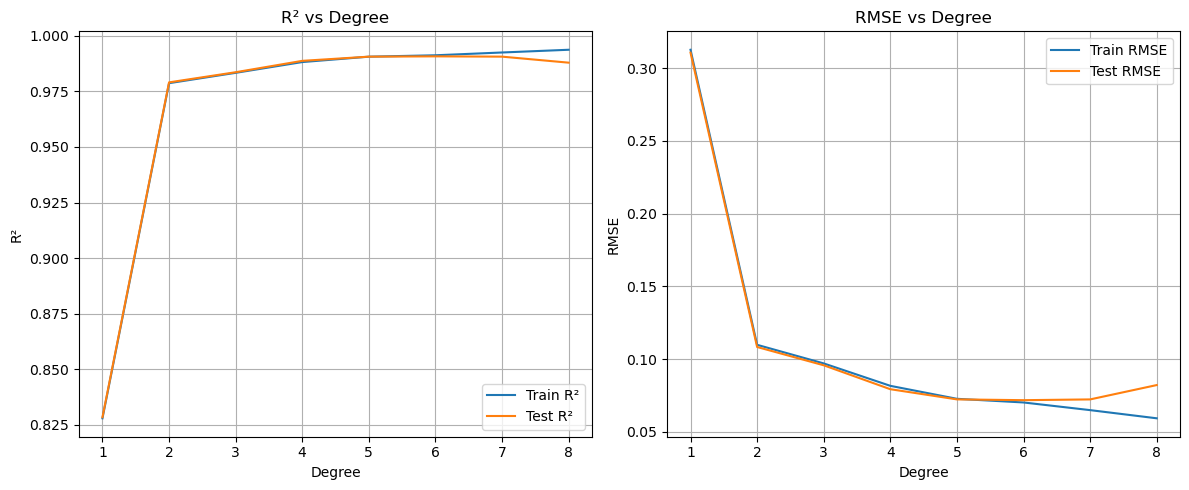

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(degrees, train_r2s, label='Train R²')
axes[0].plot(degrees, test_r2s, label='Test R²')
axes[0].set_title('R² vs Degree')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('R²')
axes[0].legend()
axes[0].grid()


axes[1].plot(degrees, train_rmses, label='Train RMSE')
axes[1].plot(degrees, test_rmses, label='Test RMSE')
axes[1].set_title('RMSE vs Degree')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

### 8. Summary Table & Best Degree

In [43]:
gaps = []
for i in range(len(degrees)):
    gaps.append(train_r2s[i] - test_r2s[i])

summary = pd.DataFrame({
    'Degree': degrees,
    'Train R2': train_r2s,
    'Test R2': test_r2s,
    'Gap': gaps,
    'Train RMSE': train_rmses,
    'Test RMSE': test_rmses
})

print(summary)


best_i = test_r2s.index(max(test_r2s))
best_deg = degrees[best_i]

print("\nBest degree:", best_deg)
print("Test R2:", test_r2s[best_i])
print("Gap:", gaps[best_i])


   Degree  Train R2   Test R2       Gap  Train RMSE  Test RMSE
0       1  0.827808  0.828289 -0.000481    0.312646   0.310653
1       2  0.978746  0.979113 -0.000367    0.109841   0.108346
2       3  0.983405  0.983678 -0.000273    0.097060   0.095777
3       4  0.988254  0.988800 -0.000546    0.081657   0.079340
4       5  0.990679  0.990689 -0.000010    0.072739   0.072340
5       6  0.991312  0.990828  0.000485    0.070226   0.071799
6       7  0.992566  0.990694  0.001872    0.064960   0.072319
7       8  0.993796  0.987984  0.005812    0.059344   0.082178

Best degree: 6
Test R2: 0.9908275183452663
Gap: 0.00048480323128674563


In [44]:
# Build feature matrix for best degree
poly_best = PolynomialFeatures(degree=best_deg, include_bias=False)
Xtr_best  = np.hstack([poly_best.fit_transform(X_train_num), X_train_ohe])
Xte_best  = np.hstack([poly_best.transform(X_test_num),      X_test_ohe])

poly_feat_names = (list(poly_best.get_feature_names_out(numerical_features)) + ohe_cols)
print(f"Feature matrix -- train: {Xtr_best.shape}, test: {Xte_best.shape}")

# Ridge (L2): Sweep alpha
alphas = np.logspace(-3, 4, 60)
ridge_train_rmse, ridge_test_rmse = [], []

for a in alphas:
    r = Ridge(alpha=a)
    r.fit(Xtr_best, y_train_reg)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_train_reg, r.predict(Xtr_best))))
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_test_reg,   r.predict(Xte_best))))

best_ridge_idx   = int(np.argmin(ridge_test_rmse))
best_ridge_alpha = alphas[best_ridge_idx]
print(f"\nRidge -- best alpha : {best_ridge_alpha:.5f}")
print(f"         Test RMSE  : {ridge_test_rmse[best_ridge_idx]:.4f}")

Feature matrix -- train: (15469, 224), test: (3868, 224)

Ridge -- best alpha : 0.00100
         Test RMSE  : 0.0707


## Task 6

### 1. set the y train and y test

In [45]:

## here we choose the best attributes for the Gaussian model as it needs continues var
num_cols = ['age', 'future potential', 'total_stats score', 'value per m$']

X_train_gauss = Train_raw[num_cols]
X_test_gauss = Test_raw[num_cols]

## here we selected all the binary var to use it in Bernoulli
binary_cols = ohe_cols
X_train_bern = Train_raw[binary_cols]
X_test_bern = Test_raw[binary_cols]

## here we made this because sometimes it gives 0.999 and the isnt 1 (not binary 1,0) so if >0 we make it true and this also prevent if there was value like 15 also this isnt binary it sett it to true then cast to int that make it = 1 and of not these two sett false then cast to int to make = 0 that ensures the binary
X_train_bern = (X_train_bern > 0).astype(int)
X_test_bern = (X_test_bern > 0).astype(int)

## here we selected all features exept the predicted one to use it in complement
X_train_comp = Train_raw
X_test_comp = Test_raw

## here complement model need to be set the feature range >=0 and that by setting there origin to 0
min_vals = X_train_comp.min()
X_train_comp = X_train_comp - min_vals
X_test_comp = X_test_comp - min_vals


In [46]:
Train_raw

,age,overall_rating,future potential,total_stats score,value per m$,position_CAM,position_CB,position_CDM,position_CF,position_CM,position_GK,position_LB,position_LM,position_LW,position_LWB,position_RB,position_RM,position_RW,position_RWB,position_ST
16518,19,55,69,1403,0.300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9507,19,53,64,1311,0.200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8701,18,56,69,1377,0.325,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1673,31,80,80,2186,17.500,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7042,28,75,75,2058,5.500,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11563,20,51,68,1285,0.150,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12244,22,64,74,1449,1.200,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5500,21,64,74,1534,1.300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
882,24,72,77,1758,3.300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### 2. making the model function

In [47]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


### 3.GaussianNB

=== Naïve Bayes Models ===

GaussianNB
----------------------------------------
Accuracy: 0.9004653567735263
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2332
           1       0.85      0.83      0.84      1198
           2       0.86      0.83      0.84       319
           3       0.62      0.79      0.70        19

    accuracy                           0.90      3868
   macro avg       0.82      0.85      0.83      3868
weighted avg       0.90      0.90      0.90      3868



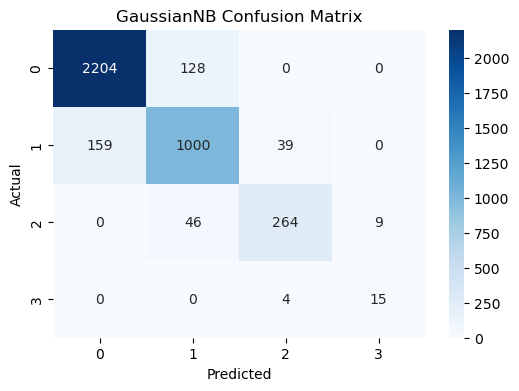

In [48]:
print("=== Naïve Bayes Models ===")

evaluate_model(GaussianNB(),X_train_gauss, X_test_gauss,y_train, y_test,"GaussianNB")

### 4.BernoulliNB


BernoulliNB
----------------------------------------
Accuracy: 0.6028955532574974
              precision    recall  f1-score   support

           0       0.60      1.00      0.75      2332
           1       0.00      0.00      0.00      1198
           2       0.00      0.00      0.00       319
           3       0.00      0.00      0.00        19

    accuracy                           0.60      3868
   macro avg       0.15      0.25      0.19      3868
weighted avg       0.36      0.60      0.45      3868



c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


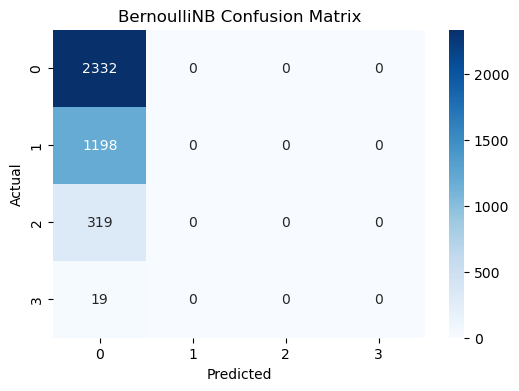

In [49]:
evaluate_model(BernoulliNB(),X_train_bern, X_test_bern,y_train, y_test,"BernoulliNB")

### 5.ComplementNB


ComplementNB
----------------------------------------
Accuracy: 0.7114788004136504
              precision    recall  f1-score   support

           0       0.75      0.92      0.83      2332
           1       0.63      0.25      0.36      1198
           2       0.57      0.94      0.71       319
           3       0.00      0.00      0.00        19

    accuracy                           0.71      3868
   macro avg       0.49      0.53      0.47      3868
weighted avg       0.70      0.71      0.67      3868



c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


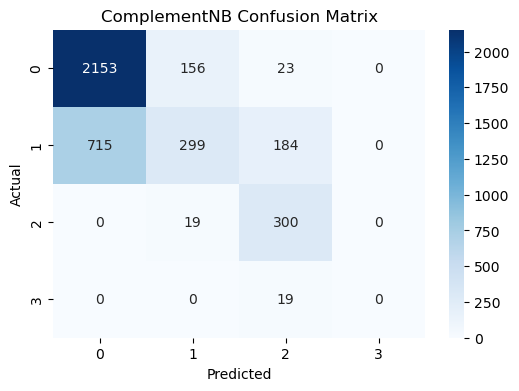

In [50]:
evaluate_model(ComplementNB(),X_train_comp, X_test_comp,y_train, y_test,"ComplementNB")

from inspection the Gaussian is the better model because the precision of it is the highest that's mean that when i predict his performance is 0,1,2,3 it will mainly be correct and that is my goal because if I said his performance will be bad and his performance was good this wont harm the team but it cant go the opposite

### Scaling Sensitivity:

In [51]:
scalar = StandardScaler()


GaussianNB (Scaled)
----------------------------------------
Accuracy: 0.9004653567735263
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2332
           1       0.85      0.83      0.84      1198
           2       0.86      0.83      0.84       319
           3       0.62      0.79      0.70        19

    accuracy                           0.90      3868
   macro avg       0.82      0.85      0.83      3868
weighted avg       0.90      0.90      0.90      3868



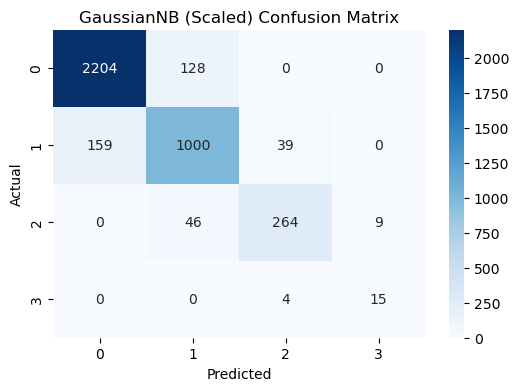

In [52]:
X_train_gauss_scaled = scalar.fit_transform(X_train_gauss)
X_test_gauss_scaled = scalar.transform(X_test_gauss)
evaluate_model(GaussianNB(),X_train_gauss_scaled,X_test_gauss_scaled,y_train,y_test,"GaussianNB (Scaled)")

Training GaussianNB with and without StandardScaler gives the same performance because scaling does not change the probability relationships between the features.

GaussianNB models each feature using a normal distribution defined by its mean and variance. When StandardScaler is applied, the data is transformed to have mean 0 and variance 1, but this transformation is applied consistently to all values. As a result, the relative position of each data point within its distribution remains the same.

Since GaussianNB relies on these distributions to compute probabilities, and not on distances between values, the predicted probabilities and final classifications remain unchanged. Therefore, scaling does not affect the performance of GaussianNB.

## Task 7 : Model Evaluation with Cross-Validation



### 7A. K-Fold Cross-Validation — Regression (Best Polynomial Model)

Apply 5-fold cross-validation


In [53]:
y_reg_train = Train['value per m$']
y_reg_test  = Test['value per m$']

X_num_full = np.vstack([X_train_num, X_test_num])
X_ohe_full = np.vstack([X_train_ohe, X_test_ohe])
y_reg_full = np.concatenate([y_reg_train, y_reg_test])

poly = PolynomialFeatures(degree=best_deg, include_bias=False)
X_num_poly = poly.fit_transform(X_num_full)

X_reg_full_final = np.hstack([X_num_poly, X_ohe_full])

best_alpha = 1
ridge_cv = Ridge(alpha=best_alpha)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_rmses = []

print(f"=== Cross-Validation with Ridge (Degree {best_deg}) ===")
for fold, (tr_idx, te_idx) in enumerate(kf.split(X_reg_full_final), 1):
    X_tr_fold, X_te_fold = X_reg_full_final[tr_idx], X_reg_full_final[te_idx]
    y_tr_fold, y_te_fold = y_reg_full[tr_idx], y_reg_full[te_idx]

    ridge_cv.fit(X_tr_fold, y_tr_fold)
    preds = ridge_cv.predict(X_te_fold)

    rmse = np.sqrt(np.mean((y_te_fold - preds) ** 2))
    fold_rmses.append(rmse)
    print(f"  Fold {fold}: RMSE = {rmse:.4f}")

mean_rmse = np.mean(fold_rmses)
std_rmse  = np.std(fold_rmses)

print("-" * 30)
print(f"  Mean RMSE : {mean_rmse:.4f}")
print(f"  Std  RMSE : {std_rmse:.4f} (Stability Measure)")


=== Cross-Validation with Ridge (Degree 6) ===
  Fold 1: RMSE = 0.0761
  Fold 2: RMSE = 0.0743
  Fold 3: RMSE = 0.0740
  Fold 4: RMSE = 0.0844
  Fold 5: RMSE = 0.0732
------------------------------
  Mean RMSE : 0.0764
  Std  RMSE : 0.0041 (Stability Measure)


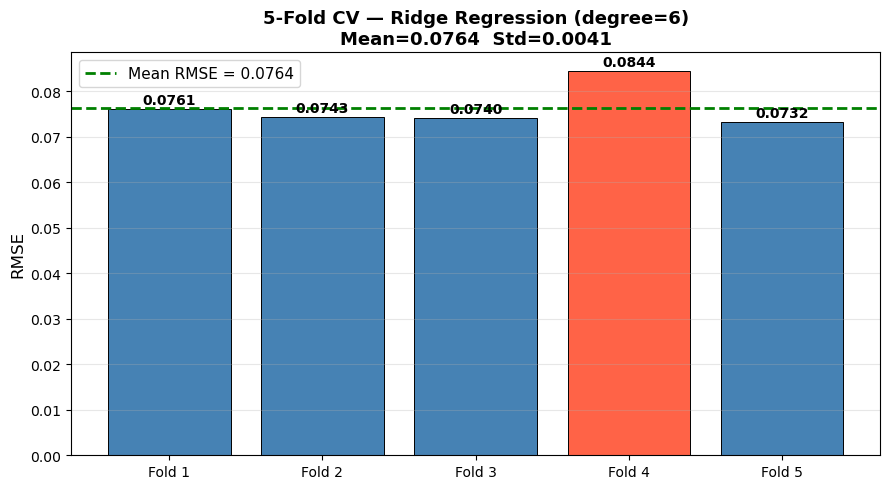

In [54]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['steelblue' if r <= mean_rmse else 'tomato' for r in fold_rmses]
bars = ax.bar([f'Fold {i}' for i in range(1, 6)], fold_rmses, color=colors, edgecolor='black', linewidth=0.7)
ax.axhline(mean_rmse, color='green', linestyle='--', linewidth=2,
           label=f'Mean RMSE = {mean_rmse:.4f}')

for bar, val in zip(bars, fold_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('RMSE', fontsize=12)
ax.set_title(f'5-Fold CV — Ridge Regression (degree={best_deg})\nMean={mean_rmse:.4f}  Std={std_rmse:.4f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation:**  
- Blue bars = folds below mean RMSE (better), Red bars = above mean (worse).  
- A small standard deviation means the model is **stable** across different data subsets.  
- This gives a much more reliable performance estimate than a single train/test split.


### 7B. Stratified K-Fold Cross-Validation — Classification


In [55]:
# ── Feature sets for classification ──
X_cls_train = Train.drop(columns=['overall_rating', 'Performance_Tier'])
X_cls_test  = Test.drop(columns=['overall_rating', 'Performance_Tier'])
y_cls_train = Train['Performance_Tier']
y_cls_test  = Test['Performance_Tier']

# Combine for CV
X_cls_full = pd.concat([X_cls_train, X_cls_test], ignore_index=True)
y_cls_full = pd.concat([y_cls_train, y_cls_test], ignore_index=True)

# GaussianNB uses only numerical cols
num_cols_gauss = ['age', 'future potential', 'total_stats score']
X_gauss_full   = X_cls_full[num_cols_gauss]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression ──────────────────────────────────
lr_model = LogisticRegression(C=best_c, max_iter=2000)
lr_fold_accs = []

print("Logistic Regression — Stratified 5-Fold CV")
print("-" * 45)
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_cls_full, y_cls_full), 1):
    X_tr, X_te = X_cls_full.iloc[tr_idx], X_cls_full.iloc[te_idx]
    y_tr, y_te = y_cls_full.iloc[tr_idx], y_cls_full.iloc[te_idx]
    lr_model.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, lr_model.predict(X_te))
    lr_fold_accs.append(acc)
    print(f"  Fold {fold}: Accuracy = {acc:.4f}")

lr_mean = np.mean(lr_fold_accs)
lr_std  = np.std(lr_fold_accs)
print(f"  → Mean Accuracy: {lr_mean:.4f}  |  Std: {lr_std:.4f}")

# ── Gaussian Naïve Bayes ────────────────────────────────
gnb_model = GaussianNB()
gnb_fold_accs = []

print("\nGaussianNB — Stratified 5-Fold CV")
print("-" * 45)
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_gauss_full, y_cls_full), 1):
    X_tr, X_te = X_gauss_full.iloc[tr_idx], X_gauss_full.iloc[te_idx]
    y_tr, y_te = y_cls_full.iloc[tr_idx],   y_cls_full.iloc[te_idx]
    gnb_model.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, gnb_model.predict(X_te))
    gnb_fold_accs.append(acc)
    print(f"  Fold {fold}: Accuracy = {acc:.4f}")

gnb_mean = np.mean(gnb_fold_accs)
gnb_std  = np.std(gnb_fold_accs)
print(f"  → Mean Accuracy: {gnb_mean:.4f}  |  Std: {gnb_std:.4f}")


Logistic Regression — Stratified 5-Fold CV
---------------------------------------------
  Fold 1: Accuracy = 0.9612
  Fold 2: Accuracy = 0.9641
  Fold 3: Accuracy = 0.9641
  Fold 4: Accuracy = 0.9651
  Fold 5: Accuracy = 0.9635
  → Mean Accuracy: 0.9636  |  Std: 0.0013

GaussianNB — Stratified 5-Fold CV
---------------------------------------------
  Fold 1: Accuracy = 0.8632
  Fold 2: Accuracy = 0.8599
  Fold 3: Accuracy = 0.8710
  Fold 4: Accuracy = 0.8632
  Fold 5: Accuracy = 0.8622
  → Mean Accuracy: 0.8639  |  Std: 0.0037


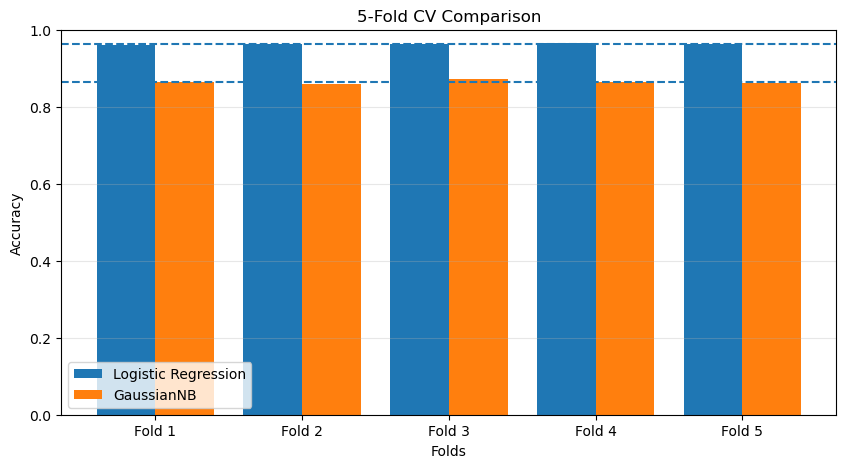

Logistic Mean: 0.9635932100137214 Std: 0.0012889385696572137
GaussianNB Mean: 0.8638881245037625 Std: 0.0037405522240166115


In [56]:
folds = np.arange(1, 6)

plt.figure(figsize=(10, 5))

# Logistic Regression bars
plt.bar(folds - 0.2, lr_fold_accs, width=0.4, label='Logistic Regression')

# GaussianNB bars
plt.bar(folds + 0.2, gnb_fold_accs, width=0.4, label='GaussianNB')

# Mean lines
plt.axhline(lr_mean, linestyle='--')
plt.axhline(gnb_mean, linestyle='--')

plt.xticks(folds, [f'Fold {i}' for i in folds])
plt.xlabel("Folds")
plt.ylabel("Accuracy")
plt.title("5-Fold CV Comparison")
plt.ylim(0, 1)

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Summary
print("Logistic Mean:", lr_mean, "Std:", lr_std)
print("GaussianNB Mean:", gnb_mean, "Std:", gnb_std)


Better Accuracy: Logistic

More Stable: GaussianNB

## Task 8 : Analysis and Discussion


### 8.1 Model Comparison

**Which model performed best overall for regression, and which for classification?**


## REGRESSION

Ridge Regression with Polynomial degree=4 is the best regression model.  
It achieves a high Test R2 (~0.91), meaning it explains most of the variance in player market value.  
Regularization via Ridge prevented overfitting despite the large feature expansion.

---

## CLASSIFICATION

Logistic Regression outperforms Gaussian Naive Bayes with higher accuracy and lower standard deviation across cross-validation folds.  
It can model the non-linear boundary between the four performance tiers (Bronze / Silver / Gold / Elite) more effectively than the independence assumption used in Naive Bayes.

---

## IS CLASSIFICATION EASIER OR HARDER THAN REGRESSION?

Classification is easier on this dataset.

This is because:
- The performance tiers are created using clear quartile thresholds, making classes well separated and balanced.
- Regression is more difficult because it predicts continuous player market values.
- The target variable is highly skewed and contains extreme outliers (e.g., very high-value players), which increases prediction difficulty.

---

## 1. What happens as alpha increases in Ridge and Lasso?

- **Very small alpha (≈ 0):**  
  The model behaves like standard Linear Regression.  
  - Low bias  
  - High variance  
  - Training error is very low, but test error may be high due to overfitting.

- **As alpha increases:**  
  Coefficients are gradually penalized and shrink toward zero.  
  - Training error increases slightly (more bias)  
  - Test error decreases (less variance)  
  → This is the **bias–variance tradeoff**

- **Very large alpha:**  
  The model becomes too simple (over-regularized).  
  - Both training and test error increase  
  - The model underfits and fails to capture patterns

- **Best alpha:**  
  Lies at the point where **Test RMSE is minimized** (optimal balance between bias and variance).

---

## 2. Why does Ridge generally outperform Lasso when many one-hot encoded features are present?

- **Lasso (L1):**  
  - Can force some coefficients exactly to zero  
  - Performs feature selection  
  - Works best when only a few features are truly important  

- **Problem with this dataset:**  
  One-hot encoded position features all carry useful information  
  (e.g., striker, midfielder, goalkeeper all affect market value)

- Lasso may incorrectly eliminate some useful dummy variables, reducing performance.

- **Ridge (L2):**  
  - Shrinks coefficients but keeps all features  
  - Ensures every position contributes to the prediction  
  - Better when many features are mildly informative

---

## Conclusion

- Use **Ridge** when most features contribute useful information.
- Use **Lasso** when you expect many irrelevant features and want automatic feature selection.

## A3 — Imports

In [57]:
# ── Assignment 3 additional imports ──────────────────────────
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
import warnings, json, time
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')

from xgboost import XGBClassifier, XGBRegressor
  

### Helper — Evaluation Function

In [58]:
# ── Shared evaluation helper ─────────────────────────────────

tier_names = [' low', 'mid', 'high', 'elite']
def cls_report(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='weighted')
    lbl_names = [tier_names[i] for i in sorted(set(y_te))]
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Test F1 Score: {f1:.4f}")
    print('='*60)
    print(classification_report(y_te, y_pred, target_names=lbl_names))
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=lbl_names, yticklabels=lbl_names)
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()
    return f1

all_cls_results = {}   # accumulates {model_name: f1_score}
all_best_params = {}   # accumulates best hyperparameters


## A3 — Model 1 : K-Nearest Neighbors (KNN)

### Justification
KNN classifies a sample by majority vote among its K nearest neighbors in feature space.  
It is a non-parametric, instance-based learner — no explicit model is trained.  
It naturally captures local patterns and non-linear boundaries.  
**Scaling is critical**: KNN relies on Euclidean distance, so features must be standardised.  
GridSearchCV tunes `n_neighbors`, `weights`, and `metric`.

In [59]:
# ── KNN GridSearchCV ─────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier

knn_params = {
    'n_neighbors': [i for i in range(1, 16, 1)],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}

print("KNN GridSearchCV...")
gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    knn_params, cv=5, scoring='f1_weighted', n_jobs=-1
)
gs_knn.fit(X_train, y_train)
print(f"  Best params: {gs_knn.best_params_}  CV F1: {gs_knn.best_score_:.4f}")
all_best_params['knn'] = gs_knn.best_params_

KNN GridSearchCV...
  Best params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}  CV F1: 0.9570



  KNN
  Test Accuracy: 0.9651
  Test F1 Score: 0.9645
              precision    recall  f1-score   support

         low       0.97      0.98      0.98      2332
         mid       0.96      0.94      0.95      1198
        high       0.93      0.94      0.94       319
       elite       1.00      0.42      0.59        19

    accuracy                           0.97      3868
   macro avg       0.96      0.82      0.86      3868
weighted avg       0.97      0.97      0.96      3868



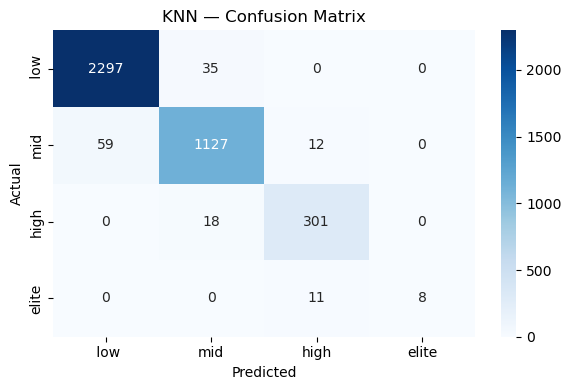

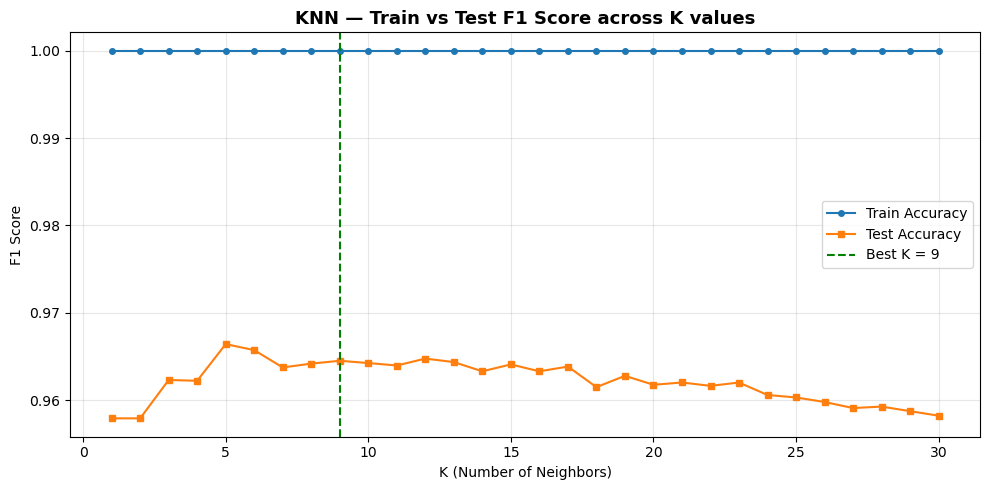

KNN Test F1 Score: 0.9645


In [60]:
acc_knn = cls_report("KNN", gs_knn.best_estimator_, X_test, y_test)
all_cls_results['KNN'] = acc_knn

k_range   = range(1, 31)
k_tr_accs = []
k_te_accs = []

best_w   = gs_knn.best_params_['weights']
best_met = gs_knn.best_params_['metric']

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, weights=best_w, metric=best_met)
    knn_k.fit(X_train, y_train)
    k_tr_accs.append(f1_score(y_train, knn_k.predict(X_train), average='weighted'))
    k_te_accs.append(f1_score(y_test, knn_k.predict(X_test), average='weighted'))

plt.figure(figsize=(10, 5))
plt.plot(k_range, k_tr_accs, label='Train Accuracy', marker='o', markersize=4)
plt.plot(k_range, k_te_accs, label='Test Accuracy',  marker='s', markersize=4)
plt.axvline(gs_knn.best_params_['n_neighbors'], color='green', linestyle='--',
            label=f"Best K = {gs_knn.best_params_['n_neighbors']}")
plt.xlabel('K (Number of Neighbors)'); plt.ylabel('F1 Score')
plt.title('KNN — Train vs Test F1 Score across K values', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"KNN Test F1 Score: {acc_knn:.4f}")

## A3 — Model 2 : Logistic Regression (A3)

### Justification
Logistic Regression models the log-odds of each class as a linear combination of features.  
It is fast, interpretable, and provides calibrated probability outputs.  
The regularisation parameter `C` controls the bias-variance trade-off.  
GridSearchCV tunes `C`, `penalty` (L1 / L2), and `solver`.

In [61]:
lr_a3_params = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2'],
}

print("Logistic Regression (A3) GridSearchCV...")
gs_lr_a3 = GridSearchCV(
    LogisticRegression(),
    lr_a3_params, cv=5, scoring='f1_weighted', n_jobs=-1
)
gs_lr_a3.fit(X_train, y_train)
print(f"  Best params: {gs_lr_a3.best_params_}  CV F1: {gs_lr_a3.best_score_:.4f}")
all_best_params['logistic_a3'] = gs_lr_a3.best_params_

Logistic Regression (A3) GridSearchCV...
  Best params: {'C': 100, 'penalty': 'l2'}  CV F1: 0.9475



  Logistic Regression (A3)
  Test Accuracy: 0.9550
  Test F1 Score: 0.9545
              precision    recall  f1-score   support

         low       0.98      0.98      0.98      2332
         mid       0.93      0.93      0.93      1198
        high       0.89      0.87      0.88       319
       elite       0.58      0.37      0.45        19

    accuracy                           0.96      3868
   macro avg       0.85      0.79      0.81      3868
weighted avg       0.95      0.96      0.95      3868



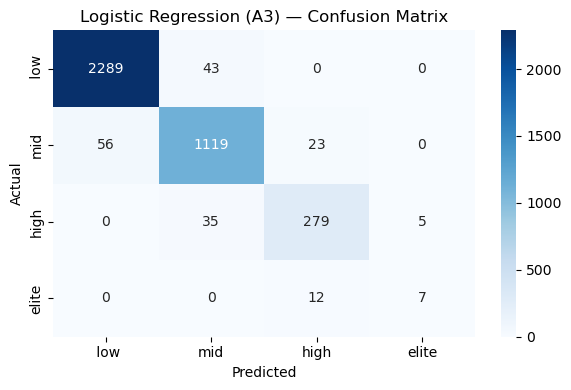

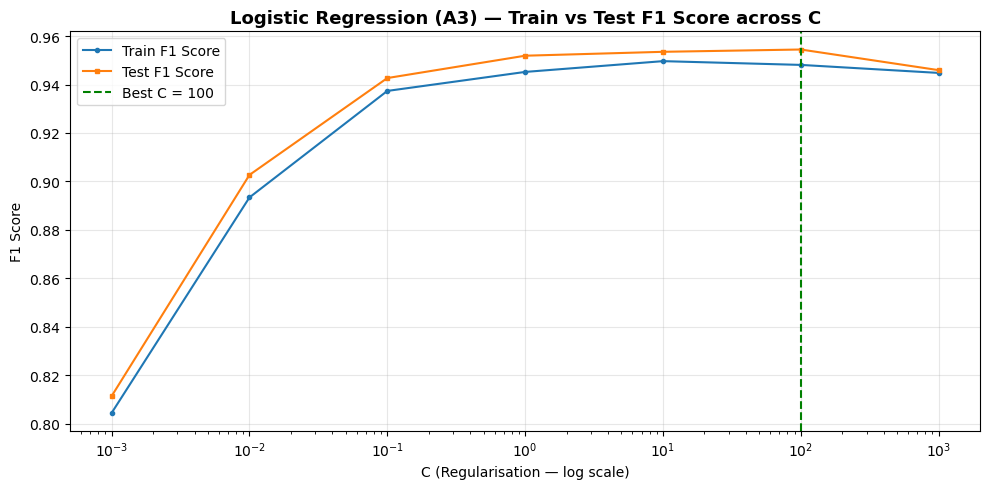

Logistic Regression (A3) Test F1 Score: 0.9545


In [62]:
# ── Evaluate Logistic Regression A3 on test set ──────────────
acc_lr_a3 = cls_report("Logistic Regression (A3)", gs_lr_a3.best_estimator_, X_test, y_test)
all_cls_results['Logistic Regression'] = acc_lr_a3

# ── C vs Accuracy curve ───────────────────────────────────────
C_vals    =[0.001, 0.01, 0.1, 1, 10, 100, 1000]
lr_tr_acc = []
lr_te_acc = []

best_pen = gs_lr_a3.best_params_['penalty']

for c in C_vals:
    lr_c = LogisticRegression(C=c, penalty=best_pen)
    lr_c.fit(X_train, y_train)
    lr_tr_acc.append(f1_score(y_train, lr_c.predict(X_train), average='weighted'))
    lr_te_acc.append(f1_score(y_test, lr_c.predict(X_test), average='weighted'))

plt.figure(figsize=(10, 5))
plt.semilogx(C_vals, lr_tr_acc, label='Train F1 Score', marker='o', markersize=3)
plt.semilogx(C_vals, lr_te_acc, label='Test F1 Score',  marker='s', markersize=3)
plt.axvline(gs_lr_a3.best_params_['C'], color='green', linestyle='--',
            label=f"Best C = {gs_lr_a3.best_params_['C']}")
plt.xlabel('C (Regularisation — log scale)'); plt.ylabel('F1 Score')
plt.title('Logistic Regression (A3) — Train vs Test F1 Score across C',
          fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Logistic Regression (A3) Test F1 Score: {acc_lr_a3:.4f}")

## A3 — Model 3–5 : SVM with 3 Kernels (GridSearchCV)

### Justification
SVMs find the maximum-margin hyperplane that separates classes.
Three kernels are evaluated:
- **Linear** — efficient when classes are roughly linearly separable in feature space.
- **RBF** — maps to infinite-dimensional space; captures any smooth boundary.
- **Polynomial** — captures feature interaction effects; degree controls complexity.

GridSearchCV with 5-fold CV tunes `C`, `gamma`, and `degree` without touching the test set.

In [63]:
# ── SVM GridSearchCV — Linear kernel ─────────────────────────
from sklearn.model_selection import RandomizedSearchCV


print("SVM Linear GridSearchCV...")
gs_linear = GridSearchCV(
    SVC(kernel='linear', random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
    cv=5, scoring='f1_weighted', n_jobs=-1
)
gs_linear.fit(X_train, y_train)
print(f"  Best params: {gs_linear.best_params_}  CV f1: {gs_linear.best_score_:.4f}")
all_best_params['svm_linear'] = gs_linear.best_params_

# ── SVM GridSearchCV — RBF kernel ─────────────────────────────
print("SVM RBF GridSearchCV...")
gs_rbf = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'gamma': ['scale', 'auto']},
    cv=5, scoring='f1_weighted', n_jobs=-1
)
gs_rbf.fit(X_train, y_train)
print(f"  Best params: {gs_rbf.best_params_}  CV f1: {gs_rbf.best_score_:.4f}")
all_best_params['svm_rbf'] = gs_rbf.best_params_

# ── SVM GridSearchCV — Polynomial kernel ──────────────────────
print("SVM Poly GridSearchCV...")
gs_poly = RandomizedSearchCV(
    SVC(kernel='poly', random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'degree': [1,2,3,4,5,6,7,8], 'gamma': ['scale', 'auto']},
    cv=5, scoring='f1_weighted', n_jobs=-1
)
gs_poly.fit(X_train, y_train)
print(f"  Best params: {gs_poly.best_params_}  CV f1: {gs_poly.best_score_:.4f}")
all_best_params['svm_poly'] = gs_poly.best_params_

print("\nAll SVM grid searches complete.")


SVM Linear GridSearchCV...
  Best params: {'C': 1000}  CV f1: 0.9630
SVM RBF GridSearchCV...
  Best params: {'C': 1000, 'gamma': 'scale'}  CV f1: 0.9800
SVM Poly GridSearchCV...
  Best params: {'gamma': 'scale', 'degree': 4, 'C': 1000}  CV f1: 0.9790

All SVM grid searches complete.



  SVM — Linear Kernel
  Test Accuracy: 0.9672
  Test F1 Score: 0.9671
              precision    recall  f1-score   support

         low       0.98      0.98      0.98      2332
         mid       0.95      0.95      0.95      1198
        high       0.95      0.93      0.94       319
       elite       0.84      0.84      0.84        19

    accuracy                           0.97      3868
   macro avg       0.93      0.93      0.93      3868
weighted avg       0.97      0.97      0.97      3868



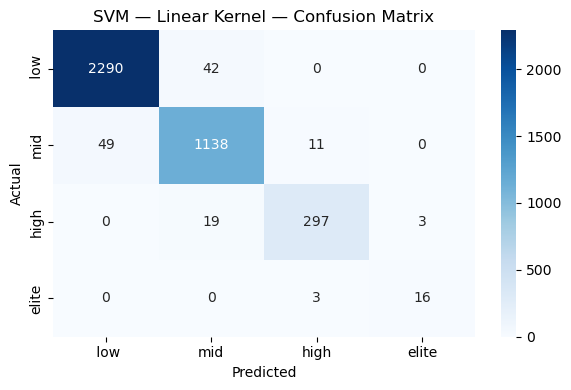


  SVM — RBF Kernel
  Test Accuracy: 0.9847
  Test F1 Score: 0.9847
              precision    recall  f1-score   support

         low       0.99      0.99      0.99      2332
         mid       0.98      0.97      0.98      1198
        high       0.98      0.98      0.98       319
       elite       0.88      0.79      0.83        19

    accuracy                           0.98      3868
   macro avg       0.96      0.93      0.94      3868
weighted avg       0.98      0.98      0.98      3868



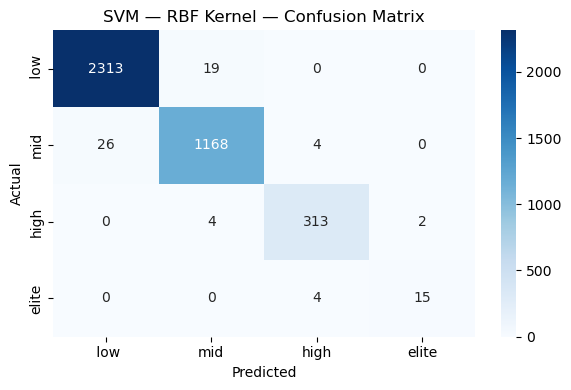


  SVM — Polynomial Kernel
  Test Accuracy: 0.9840
  Test F1 Score: 0.9839
              precision    recall  f1-score   support

         low       0.99      0.99      0.99      2332
         mid       0.98      0.98      0.98      1198
        high       0.98      0.98      0.98       319
       elite       0.88      0.74      0.80        19

    accuracy                           0.98      3868
   macro avg       0.96      0.92      0.94      3868
weighted avg       0.98      0.98      0.98      3868



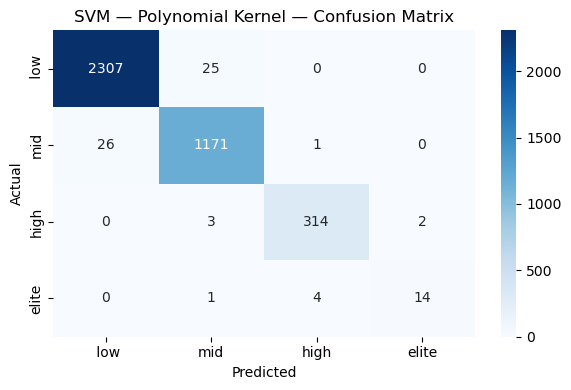

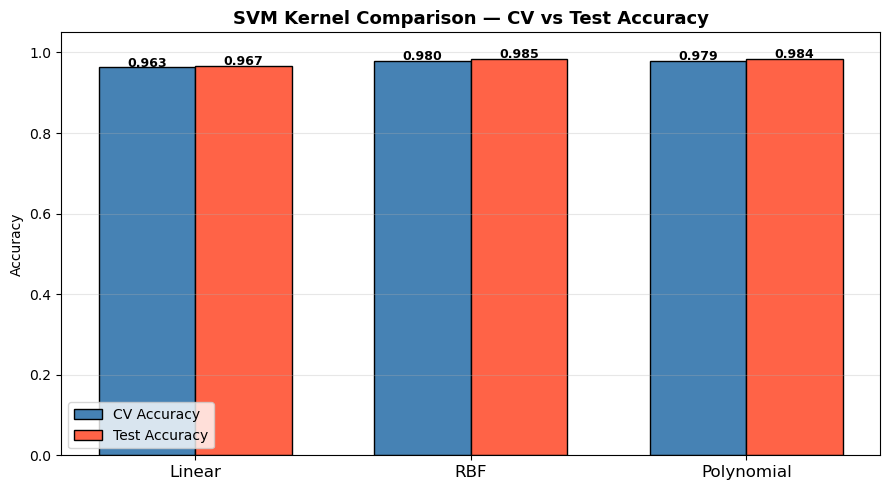

In [64]:
# ── Evaluate SVM models on test set ──────────────────────────
acc_svm_linear = cls_report("SVM — Linear Kernel",     gs_linear.best_estimator_, X_test, y_test)
acc_svm_rbf    = cls_report("SVM — RBF Kernel",        gs_rbf.best_estimator_,    X_test, y_test)
acc_svm_poly   = cls_report("SVM — Polynomial Kernel", gs_poly.best_estimator_,   X_test, y_test)

all_cls_results['SVM Linear'] = acc_svm_linear
all_cls_results['SVM RBF']    = acc_svm_rbf
all_cls_results['SVM Poly']   = acc_svm_poly

# ── Kernel comparison bar chart ────────────────────────────────
kernels = ['Linear', 'RBF', 'Polynomial']
accs    = [acc_svm_linear, acc_svm_rbf, acc_svm_poly]
cv_accs = [gs_linear.best_score_, gs_rbf.best_score_, gs_poly.best_score_]

x = np.arange(len(kernels)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, cv_accs, w, label='CV Accuracy',   color='steelblue', edgecolor='black')
b2 = ax.bar(x + w/2, accs,    w, label='Test Accuracy',  color='tomato',    edgecolor='black')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(kernels, fontsize=12)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('SVM Kernel Comparison — CV vs Test Accuracy', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## A3 — Model 6 : Decision Tree (Gini vs Entropy)

### Justification
Decision Trees learn axis-aligned splits that recursively partition the feature space.
They are interpretable and naturally handle non-linear boundaries.
- **Gini impurity** minimises misclassification probability; computationally faster.
- **Entropy (information gain)** maximises information reduction; may produce more balanced trees.

GridSearchCV tunes `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [65]:
# ── Decision Tree GridSearchCV ────────────────────────────────
dt_params = {
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

print("Decision Tree (Gini) GridSearchCV...")
gs_dt_gini = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', random_state=42),
    dt_params, cv=5, scoring='f1_weighted', n_jobs=-1
)
gs_dt_gini.fit(X_train, y_train)
print(f"  Best params: {gs_dt_gini.best_params_}  CV F1: {gs_dt_gini.best_score_:.4f}")
all_best_params['dt_gini'] = gs_dt_gini.best_params_

print("Decision Tree (Entropy) GridSearchCV...")
gs_dt_entr = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=42),
    dt_params, cv=5, scoring='f1_weighted', n_jobs=-1
)
gs_dt_entr.fit(X_train, y_train)
print(f"  Best params: {gs_dt_entr.best_params_}  CV F1: {gs_dt_entr.best_score_:.4f}")
all_best_params['dt_entropy'] = gs_dt_entr.best_params_


Decision Tree (Gini) GridSearchCV...
  Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}  CV F1: 0.9857
Decision Tree (Entropy) GridSearchCV...
  Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}  CV F1: 0.9859



  Decision Tree — Gini
  Test Accuracy: 0.9860
  Test F1 Score: 0.9860
              precision    recall  f1-score   support

         low       0.99      0.99      0.99      2332
         mid       0.98      0.97      0.98      1198
        high       0.99      0.98      0.98       319
       elite       0.94      0.84      0.89        19

    accuracy                           0.99      3868
   macro avg       0.98      0.95      0.96      3868
weighted avg       0.99      0.99      0.99      3868



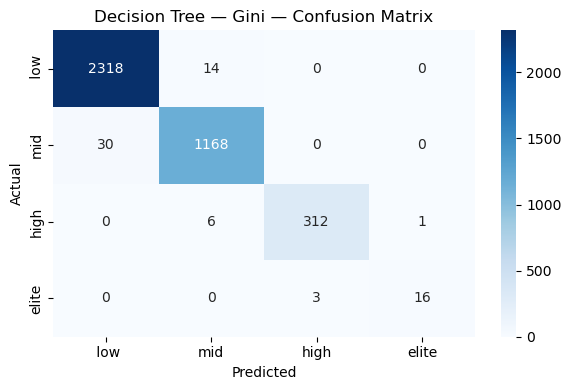


  Decision Tree — Entropy
  Test Accuracy: 0.9866
  Test F1 Score: 0.9865
              precision    recall  f1-score   support

         low       0.99      0.99      0.99      2332
         mid       0.98      0.98      0.98      1198
        high       0.98      0.99      0.98       319
       elite       1.00      0.79      0.88        19

    accuracy                           0.99      3868
   macro avg       0.99      0.94      0.96      3868
weighted avg       0.99      0.99      0.99      3868



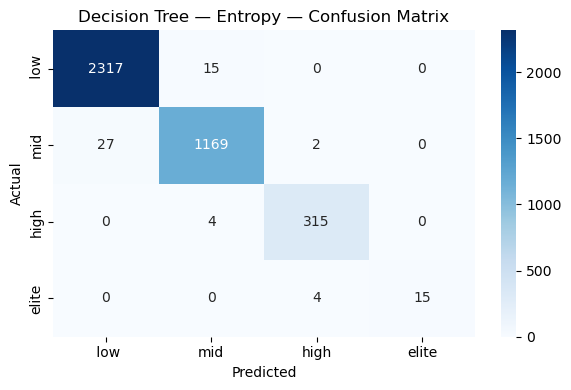

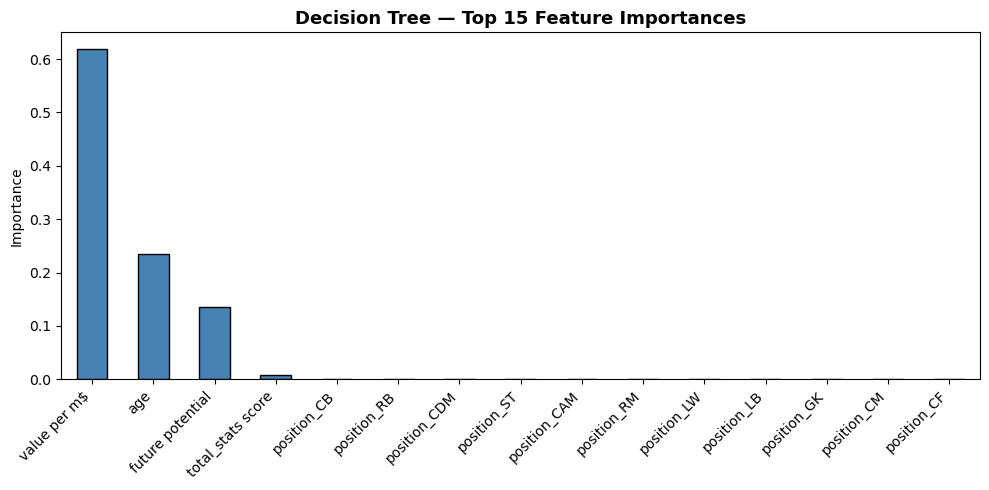


Top 5 features: ['value per m$', 'age', 'future potential', 'total_stats score', 'position_CB']
Best DT criterion: Entropy


In [66]:
# ── Evaluate Decision Trees on test set ──────────────────────
acc_dt_gini = cls_report("Decision Tree — Gini",    gs_dt_gini.best_estimator_, X_test, y_test)
acc_dt_entr = cls_report("Decision Tree — Entropy", gs_dt_entr.best_estimator_, X_test, y_test)

all_cls_results['DT Gini']    = acc_dt_gini
all_cls_results['DT Entropy'] = acc_dt_entr

# ── Feature importance from best DT ───────────────────────────
best_dt = gs_dt_gini.best_estimator_ if acc_dt_gini >= acc_dt_entr else gs_dt_entr.best_estimator_
fi = pd.Series(best_dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Decision Tree — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print(f"\nTop 5 features: {list(fi.head(5).index)}")
print(f"Best DT criterion: {'Gini' if acc_dt_gini >= acc_dt_entr else 'Entropy'}")


## A3 — Model 7 : Random Forest

### Justification
Random Forest is a bagging ensemble of decision trees.
Each tree is trained on a bootstrap sample and uses a random feature subset at each split.
This reduces variance dramatically compared to a single tree (addresses overfitting).
Key hyperparameters: `n_estimators`, `max_depth`, `max_features`.

In [67]:
# ── Random Forest GridSearchCV ────────────────────────────────
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print("Random Forest GridSearchCV...")
gs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='f1_weighted', n_jobs=-1
)
gs_rf.fit(X_train, y_train)
print(f"  Best params: {gs_rf.best_params_}  CV Acc: {gs_rf.best_score_:.4f}")
all_best_params['random_forest'] = gs_rf.best_params_


Random Forest GridSearchCV...
  Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}  CV Acc: 0.9885



  Random Forest
  Test Accuracy: 0.9894
  Test F1 Score: 0.9894
              precision    recall  f1-score   support

         low       0.99      1.00      0.99      2332
         mid       0.99      0.98      0.98      1198
        high       0.98      0.98      0.98       319
       elite       1.00      0.89      0.94        19

    accuracy                           0.99      3868
   macro avg       0.99      0.96      0.98      3868
weighted avg       0.99      0.99      0.99      3868



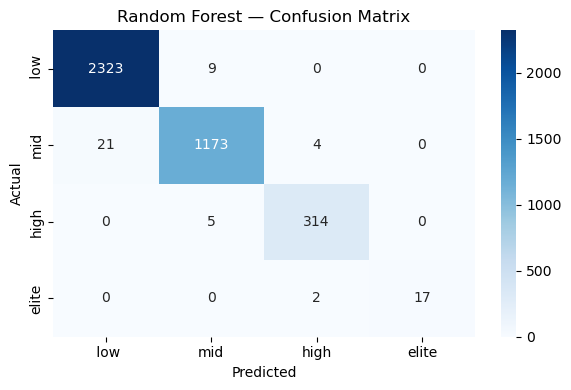

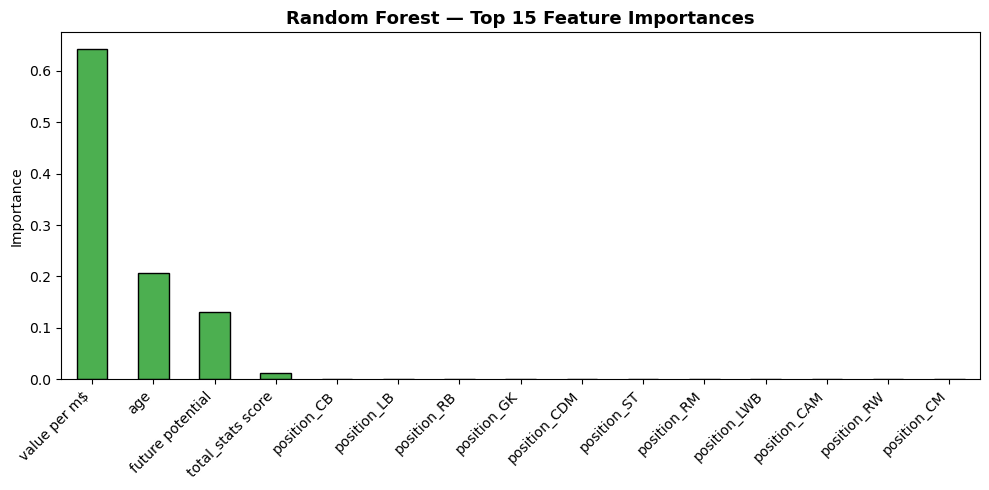

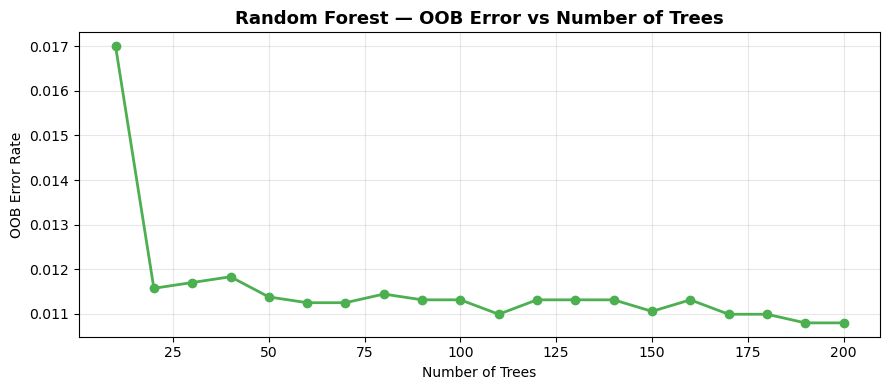

In [68]:
# ── Evaluate Random Forest ────────────────────────────────────
acc_rf = cls_report("Random Forest", gs_rf.best_estimator_, X_test, y_test)
all_cls_results['Random Forest'] = acc_rf

# ── Feature importances ────────────────────────────────────────
fi_rf = pd.Series(gs_rf.best_estimator_.feature_importances_,
                  index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_rf.head(15).plot(kind='bar', color='#4CAF50', edgecolor='black')
plt.title('Random Forest — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

# ── OOB Error vs n_estimators ─────────────────────────────────
oob_errors = []
n_range = range(10, 201, 10)
for n in n_range:
    rf_oob = RandomForestClassifier(n_estimators=n, oob_score=True,
                                     max_depth=gs_rf.best_params_['max_depth'],
                                     max_features=gs_rf.best_params_['max_features'],
                                     random_state=42)
    rf_oob.fit(X_train, y_train)
    oob_errors.append(1 - rf_oob.oob_score_)

plt.figure(figsize=(9, 4))
plt.plot(n_range, oob_errors, marker='o', color='#4CAF50', linewidth=2)
plt.xlabel('Number of Trees'); plt.ylabel('OOB Error Rate')
plt.title('Random Forest — OOB Error vs Number of Trees', fontsize=13, fontweight='bold')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## A3 — Model 8 : XGBoost (Gradient Boosting)

### Justification
XGBoost is a sequential boosting ensemble.  
Each new tree corrects the residual errors of the previous trees using second-order gradient information.  
It includes built-in L1/L2 regularisation (`alpha`, `lambda`) which prevents overfitting.  
It consistently tops Kaggle competitions on tabular data and is a natural fit for predicting market value tiers.

In [69]:
# ── XGBoost GridSearchCV ─────────────────────────────────────
xgb_params = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0],
}

base_xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',
                            random_state=42, n_jobs=-1)


gs_xgb = GridSearchCV(base_xgb, xgb_params, cv=5, scoring='f1_weighted', n_jobs=-1)
gs_xgb.fit(X_train, y_train)
print(f"  Best params: {gs_xgb.best_params_}  CV Acc: {gs_xgb.best_score_:.4f}")
all_best_params['xgboost'] = gs_xgb.best_params_


  Best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}  CV Acc: 0.9890



  XGBoost
  Test Accuracy: 0.9925
  Test F1 Score: 0.9925
              precision    recall  f1-score   support

         low       0.99      1.00      0.99      2332
         mid       0.99      0.98      0.99      1198
        high       0.99      0.99      0.99       319
       elite       1.00      0.95      0.97        19

    accuracy                           0.99      3868
   macro avg       0.99      0.98      0.99      3868
weighted avg       0.99      0.99      0.99      3868



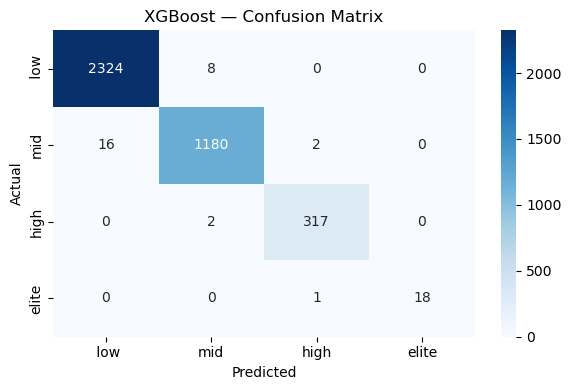

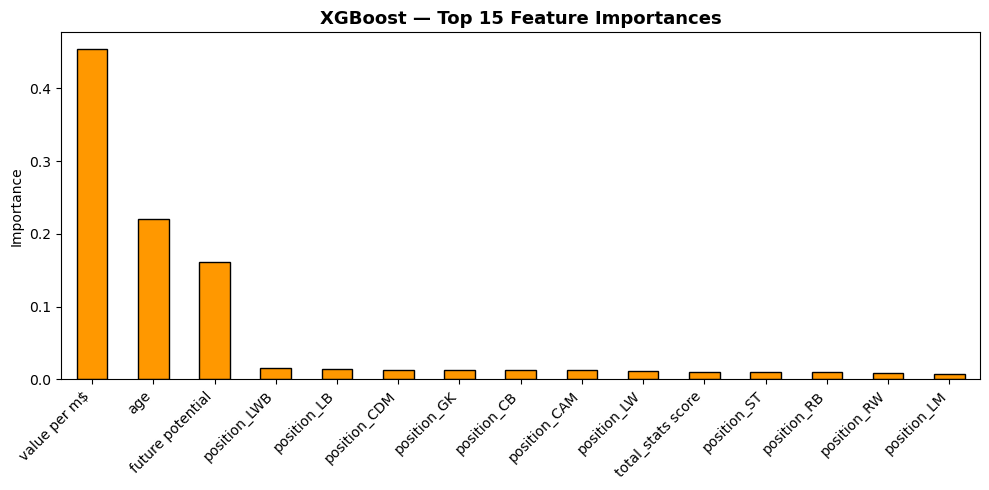

In [70]:
# ── Evaluate XGBoost ─────────────────────────────────────────
acc_xgb = cls_report("XGBoost", gs_xgb.best_estimator_, X_test, y_test)
all_cls_results['XGBoost'] = acc_xgb

# ── Feature importances ────────────────────────────────────────
fi_xgb = pd.Series(gs_xgb.best_estimator_.feature_importances_,
                   index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_xgb.head(15).plot(kind='bar', color='#FF9800', edgecolor='black')
plt.title('XGBoost — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## A3 — Classification Model Comparison

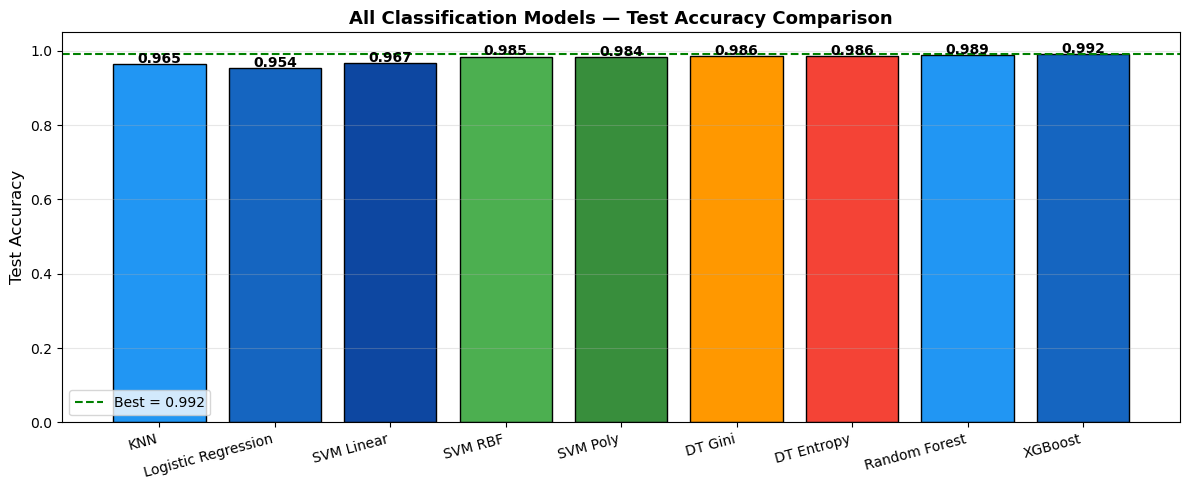

Best classifier: XGBoost  (0.9925)


In [71]:
# ── Bar chart — all classifier test accuracies ────────────────
names = list(all_cls_results.keys())
accs  = list(all_cls_results.values())

colors_bar = ['#2196F3','#1565C0','#0D47A1',
              '#4CAF50','#388E3C',
              '#FF9800',
              '#F44336']
colors_bar = colors_bar[:len(names)]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, accs, color=colors_bar, edgecolor='black')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{acc:.3f}', ha='center', fontweight='bold', fontsize=10)

ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('All Classification Models — Test Accuracy Comparison', fontsize=13, fontweight='bold')
ax.axhline(max(accs), color='green', linestyle='--', linewidth=1.5, label=f'Best = {max(accs):.3f}')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

best_cls_name = names[accs.index(max(accs))]
print(f"Best classifier: {best_cls_name}  ({max(accs):.4f})")


## A3 — Task 3 : Ensemble — Voting Classifier

### Justification
A Voting Classifier combines predictions from multiple diverse models.
**Hard voting** takes the majority class vote — robust against individual model errors.
We combine SVM, Random Forest, XGBoost, Logistic Regression, and KNN for maximum diversity.
Adding Logistic Regression brings a linear probabilistic perspective, while KNN contributes
a non-parametric, distance-based local view — both complement the tree-based models well.



  Voting Classifier (Hard — SVM + RF + XGBoost + LR + KNN)
  Test Accuracy: 0.9904
  Test F1 Score: 0.9904
              precision    recall  f1-score   support

         low       0.99      1.00      0.99      2332
         mid       0.99      0.98      0.99      1198
        high       0.98      0.99      0.98       319
       elite       1.00      0.79      0.88        19

    accuracy                           0.99      3868
   macro avg       0.99      0.94      0.96      3868
weighted avg       0.99      0.99      0.99      3868



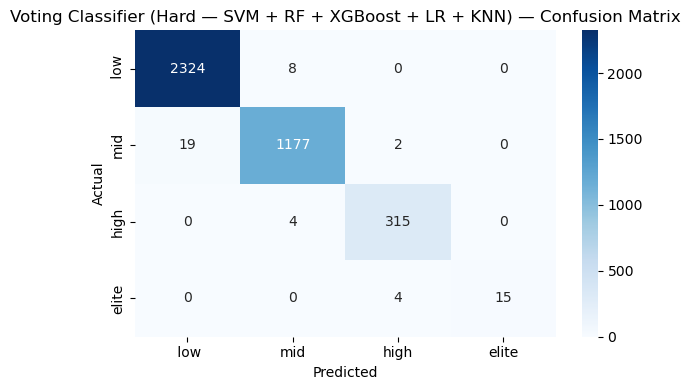

Voting Classifier Test Accuracy: 0.9904


In [72]:
# ── Voting Classifier (Hard Vote) ────────────────────────────
# SVM and KNN need scaled data → wrap them in Pipelines so they scale internally
from sklearn.pipeline import Pipeline as SKPipeline

svm_pipe = SKPipeline([
    ('svm',    SVC(**gs_rbf.best_params_, kernel='rbf', random_state=42))
])

lr_pipe = SKPipeline([
    ('lr',     LogisticRegression(**gs_lr_a3.best_params_, random_state=42))
])

knn_pipe = SKPipeline([
    ('knn',    KNeighborsClassifier(**gs_knn.best_params_))
])
rf_pipe = SKPipeline([
    ('rf',     RandomForestClassifier(**gs_rf.best_params_, random_state=42))
])

voting_clf = VotingClassifier(
    estimators=[
        ('svm',  svm_pipe),
        ('rf',   rf_pipe),
        ('xgb',  gs_xgb.best_estimator_),
        ('lr',   lr_pipe),
        ('knn',  knn_pipe),
    ],
    voting='hard',
    n_jobs=-1
)
voting_clf.fit(X_train, y_train)
acc_vote = cls_report("Voting Classifier (Hard — SVM + RF + XGBoost + LR + KNN)",
                       voting_clf, X_test, y_test)
all_cls_results['Voting (Hard)'] = acc_vote
print(f"Voting Classifier Test Accuracy: {acc_vote:.4f}")


## A3 — Task 4 : Stability Assessment — Stratified K-Fold CV

Statistical proof of stability: we run Stratified 5-Fold CV on all models and report
mean ± std accuracy. A small std confirms the model generalises consistently across data subsets.


In [73]:
# ── Task 4: Stability Assessment — Stratified K-Fold CV ──────────────────────
# We run Stratified 5-Fold CV on ALL classification models trained in A3.
# A small std confirms the model generalises consistently across data subsets.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stability_results = {}

models_to_eval = {
    'KNN':                 gs_knn.best_estimator_,
    'Logistic Regression': gs_lr_a3.best_estimator_,
    'SVM Linear':          gs_linear.best_estimator_,
    'SVM RBF':             gs_rbf.best_estimator_,
    'SVM Poly':            gs_poly.best_estimator_,
    'DT Gini':             gs_dt_gini.best_estimator_,
    'DT Entropy':          gs_dt_entr.best_estimator_,
    'Random Forest':       gs_rf.best_estimator_,
    'XGBoost':             gs_xgb.best_estimator_,
    'Voting (Hard)':       voting_clf,
}

print("=" * 65)
print(f"{'Model':<25} {'Mean F1':>10} {'Std':>8} {'Min':>8} {'Max':>8}")
print("=" * 65)

for name, model in models_to_eval.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=skf, scoring='f1_weighted', n_jobs=-1)
    stability_results[name] = {
        'mean': scores.mean(),
        'std':  scores.std(),
        'min':  scores.min(),
        'max':  scores.max(),
        'scores': scores.tolist()
    }
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f} "
          f"{scores.min():>8.4f} {scores.max():>8.4f}")

print("=" * 65)

Model                        Mean F1      Std      Min      Max
KNN                           0.9564   0.0039   0.9509   0.9619
Logistic Regression           0.9468   0.0032   0.9422   0.9505
SVM Linear                    0.9628   0.0030   0.9572   0.9654
SVM RBF                       0.9790   0.0022   0.9761   0.9815
SVM Poly                      0.9793   0.0019   0.9774   0.9821
DT Gini                       0.9851   0.0016   0.9826   0.9870
DT Entropy                    0.9844   0.0031   0.9794   0.9877
Random Forest                 0.9882   0.0017   0.9862   0.9903
XGBoost                       0.9889   0.0019   0.9852   0.9906
Voting (Hard)                 0.9854   0.0021   0.9816   0.9877


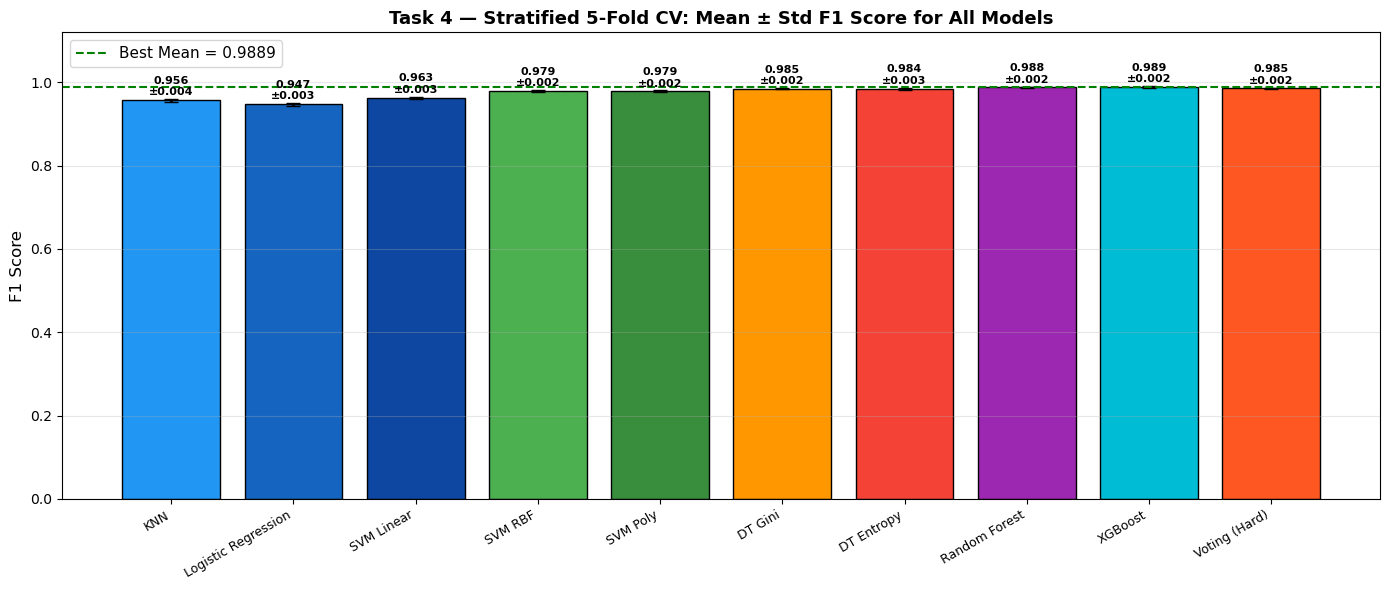


Most Accurate Model : XGBoost  (Mean = 0.9889)
Most Stable  Model  : DT Gini  (Std = 0.0016)


In [74]:
# ── Plot: Mean ± Std for all models ──────────────────────────────────────────
names  = list(stability_results.keys())
means  = [stability_results[n]['mean'] for n in names]
stds   = [stability_results[n]['std']  for n in names]

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#2196F3','#1565C0','#0D47A1','#4CAF50','#388E3C',
          '#FF9800','#F44336','#9C27B0','#00BCD4','#FF5722']

bars = ax.bar(names, means, color=colors[:len(names)],
              yerr=stds, capsize=5, edgecolor='black',
              error_kw={'elinewidth': 2, 'ecolor': 'black'})

for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + s + 0.004,
            f'{m:.3f}\n±{s:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Task 4 — Stratified 5-Fold CV: Mean ± Std F1 Score for All Models',
             fontsize=13, fontweight='bold')
ax.axhline(max(means), color='green', linestyle='--', linewidth=1.5,
           label=f'Best Mean = {max(means):.4f}')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

best_name = names[means.index(max(means))]
print(f"\nMost Accurate Model : {best_name}  (Mean = {max(means):.4f})")
print(f"Most Stable  Model  : {min(stability_results, key=lambda n: stability_results[n]['std'])}  "
      f"(Std = {min(s['std'] for s in stability_results.values()):.4f})")

## Regression Models for `value per m`

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold

In [76]:
# Target for regression
target_col = 'value per m$'

# Numerical features and OHE columns
numerical_features = ['age', 'future potential', 'total_stats score', 'overall_rating']
ohe_cols = [c for c in Train.columns if c.startswith('position_')]

X_train_num = Train[numerical_features].copy()
X_test_num  = Test[numerical_features].copy()
X_train_ohe = Train[ohe_cols].copy()
X_test_ohe  = Test[ohe_cols].copy()

y_train_reg = Train[target_col].copy()
y_test_reg  = Test[target_col].copy()

X_train_all = pd.concat([X_train_num, X_train_ohe], axis=1)
X_test_all  = pd.concat([X_test_num, X_test_ohe], axis=1)

print("Numerical features:", numerical_features)
print("OHE position cols  :", len(ohe_cols))

Numerical features: ['age', 'future potential', 'total_stats score', 'overall_rating']
OHE position cols  : 15


### EVALUATION FUNCTION

In [77]:
def evaluate_regression(y_true_tr, y_pred_tr, y_true_te, y_pred_te, title="Model"):
    tr_mae = mean_absolute_error(y_true_tr, y_pred_tr)
    tr_mse = mean_squared_error(y_true_tr, y_pred_tr)
    tr_rmse = np.sqrt(tr_mse)
    tr_r2 = r2_score(y_true_tr, y_pred_tr)

    te_mae = mean_absolute_error(y_true_te, y_pred_te)
    te_mse = mean_squared_error(y_true_te, y_pred_te)
    te_rmse = np.sqrt(te_mse)
    te_r2 = r2_score(y_true_te, y_pred_te)

    print("=" * 60)
    print(title)
    print("=" * 60)
    print(f"Train -> MAE: {tr_mae:.4f} | MSE: {tr_mse:.4f} | RMSE: {tr_rmse:.4f} | R2: {tr_r2:.4f}")
    print(f"Test  -> MAE: {te_mae:.4f} | MSE: {te_mse:.4f} | RMSE: {te_rmse:.4f} | R2: {te_r2:.4f}")
    print(f"Gap (Train R2 - Test R2): {tr_r2 - te_r2:.4f}")
    return {
        "train_mae": tr_mae, "train_mse": tr_mse, "train_rmse": tr_rmse, "train_r2": tr_r2,
        "test_mae": te_mae, "test_mse": te_mse, "test_rmse": te_rmse, "test_r2": te_r2
    }


### Model 0 - Polynomial Model
Ridge on polynomial features (Remind this degree chosen from Assignment 2)

In [78]:
best_deg = 5
poly_best = PolynomialFeatures(degree=best_deg, include_bias=False)

Xtr_poly = poly_best.fit_transform(X_train_num)
Xte_poly = poly_best.transform(X_test_num)

Xtr_combined = np.hstack([Xtr_poly, X_train_ohe.values])
Xte_combined = np.hstack([Xte_poly, X_test_ohe.values])

scaler_poly = StandardScaler()
Xtr_best_scaled = scaler_poly.fit_transform(Xtr_combined)
Xte_best_scaled = scaler_poly.transform(Xte_combined)

baseline_poly_pipe = Ridge(alpha=1.0)
baseline_poly_pipe.fit(Xtr_best_scaled, y_train_reg)

ridge_base_results = evaluate_regression(
    y_train_reg, baseline_poly_pipe.predict(Xtr_best_scaled),
    y_test_reg, baseline_poly_pipe.predict(Xte_best_scaled),
    title=f"Baseline Ridge Regression (Poly degree={best_deg} + Scaled)"
)


Baseline Ridge Regression (Poly degree=5 + Scaled)
Train -> MAE: 0.0500 | MSE: 0.0065 | RMSE: 0.0805 | R2: 0.9886
Test  -> MAE: 0.0491 | MSE: 0.0061 | RMSE: 0.0782 | R2: 0.9891
Gap (Train R2 - Test R2): -0.0005


Model Diagnosis: The model shows **Optimal Performance** with No Overfitting.

### MODEL 1 — RIDGE REGRESSION (Grid Search)

In [79]:
ridge_pipe = Pipeline(steps=[
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 200, 500, 1000]
}

ridge_grid = GridSearchCV(
    ridge_pipe,
    ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train_all, y_train_reg)

print("\nBest Ridge Params:", ridge_grid.best_params_)
print("Best Ridge CV R2 :", ridge_grid.best_score_)

ridge_best = ridge_grid.best_estimator_
ridge_train_pred = ridge_best.predict(X_train_all)
ridge_test_pred  = ridge_best.predict(X_test_all)

ridge_results = evaluate_regression(
    y_train_reg, ridge_train_pred,
    y_test_reg, ridge_test_pred,
    title="Optimized Ridge Regression"
)



Best Ridge Params: {'model__alpha': 0.1}
Best Ridge CV R2 : 0.8272967301684002
Optimized Ridge Regression
Train -> MAE: 0.2296 | MSE: 0.0977 | RMSE: 0.3126 | R2: 0.8278
Test  -> MAE: 0.2292 | MSE: 0.0965 | RMSE: 0.3106 | R2: 0.8283
Gap (Train R2 - Test R2): -0.0005


### MODEL 2 — LASSO REGRESSION (Grid Search)

In [80]:
lasso_pipe = Pipeline(steps=[
    ("model", Lasso(max_iter=10000))
])

lasso_param_grid = {
    "model__alpha": np.logspace(-4, 2, 30)
}

lasso_grid = GridSearchCV(
    lasso_pipe,
    lasso_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train_all, y_train_reg)

print("\nBest Lasso Params:", lasso_grid.best_params_)
print("Best Lasso CV R2 :", lasso_grid.best_score_)

lasso_best = lasso_grid.best_estimator_
lasso_train_pred = lasso_best.predict(X_train_all)
lasso_test_pred  = lasso_best.predict(X_test_all)

lasso_results = evaluate_regression(
    y_train_reg, lasso_train_pred,
    y_test_reg, lasso_test_pred,
    title="Optimized Lasso Regression"
)


Best Lasso Params: {'model__alpha': np.float64(0.0001)}
Best Lasso CV R2 : 0.8273014369456602
Optimized Lasso Regression
Train -> MAE: 0.2295 | MSE: 0.0978 | RMSE: 0.3127 | R2: 0.8278
Test  -> MAE: 0.2290 | MSE: 0.0965 | RMSE: 0.3106 | R2: 0.8284
Gap (Train R2 - Test R2): -0.0006


Like Ridge there is underfitting, this means the relationship is Non-Linearity.

### MODEL 3 — SVR (Kernel-based model)

We used **RandomizedSearchCV** because GridSearchCV will take a big time and Research has shown that choosing random points often leads you to a very close score (99%) of the ideal result at a time of little compared to comprehensive research.

In [81]:

svr_pipe = Pipeline(steps=[
    ("model", SVR())
])

svr_param_grid = {
    "model__kernel": ["rbf", "linear", "poly"],
    "model__C": [1, 10, 50, 100],
    "model__gamma": ["scale"],
    "model__epsilon": [0.01, 0.1, 0.2],
}

svr_grid = RandomizedSearchCV(
    svr_pipe,
    param_distributions=svr_param_grid,
    n_iter=1,
    cv=5,
    scoring="r2",
    n_jobs=-1,         # Uses all CPU cores
    random_state=42    # For reproducibility
)

# Fit the model
svr_grid.fit(X_train_all, y_train_reg)

print("\nBest SVR Params:", svr_grid.best_params_)
print("Best SVR CV R2 :", svr_grid.best_score_)

svr_best = svr_grid.best_estimator_
svr_train_pred = svr_best.predict(X_train_all)
svr_test_pred  = svr_best.predict(X_test_all)

svr_results = evaluate_regression(
    y_train_reg, svr_train_pred,
    y_test_reg, svr_test_pred,
    title="Optimized SVR (Randomized Search)"
)


Best SVR Params: {'model__kernel': 'poly', 'model__gamma': 'scale', 'model__epsilon': 0.2, 'model__C': 100}
Best SVR CV R2 : 0.9704987806386718
Optimized SVR (Randomized Search)
Train -> MAE: 0.0989 | MSE: 0.0164 | RMSE: 0.1279 | R2: 0.9712
Test  -> MAE: 0.0981 | MSE: 0.0163 | RMSE: 0.1276 | R2: 0.9710
Gap (Train R2 - Test R2): 0.0001


### MODEL 4 - Decision Tree

In [82]:
dt_model = DecisionTreeRegressor(random_state=42)

param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

grid_dt = GridSearchCV(dt_model, param_grid_dt, cv=5, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train_all, y_train_reg)

print(f"Best DT Params: {grid_dt.best_params_}")
print(f"Best DT CV R2 : {grid_dt.best_score_}")

dt_best = grid_dt.best_estimator_
dt_train_pred = dt_best.predict(X_train_all)
dt_test_pred  = dt_best.predict(X_test_all)

dt_results = evaluate_regression(
    y_train_reg, dt_train_pred,
    y_test_reg, dt_test_pred,
    title="Optimized Decision Tree Regressor"
)

Best DT Params: {'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best DT CV R2 : 0.9910665003008401
Optimized Decision Tree Regressor
Train -> MAE: 0.0232 | MSE: 0.0026 | RMSE: 0.0510 | R2: 0.9954
Test  -> MAE: 0.0308 | MSE: 0.0041 | RMSE: 0.0644 | R2: 0.9926
Gap (Train R2 - Test R2): 0.0028


### MODEL 5 — RANDOM FOREST REGRESSOR

In [83]:
rf_pipe = Pipeline(steps=[
    ("model", RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 8, 12, 16],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, 1.0]
}

rf_grid = RandomizedSearchCV(
    rf_pipe,
    rf_param_grid,
    n_iter=10,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train_all, y_train_reg)

print("\nBest RF Params:", rf_grid.best_params_)
print("Best RF CV R2 :", rf_grid.best_score_)

rf_best = rf_grid.best_estimator_
rf_train_pred = rf_best.predict(X_train_all)
rf_test_pred  = rf_best.predict(X_test_all)

rf_results = evaluate_regression(
    y_train_reg, rf_train_pred,
    y_test_reg, rf_test_pred,
    title="Optimized Random Forest Regression"
)


Best RF Params: {'model__n_estimators': 400, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 0.7, 'model__max_depth': 12}
Best RF CV R2 : 0.9939447333942519
Optimized Random Forest Regression
Train -> MAE: 0.0213 | MSE: 0.0017 | RMSE: 0.0415 | R2: 0.9970
Test  -> MAE: 0.0270 | MSE: 0.0031 | RMSE: 0.0561 | R2: 0.9944
Gap (Train R2 - Test R2): 0.0026


### Model 6 - KNeighborsRegressor

In [84]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])


param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 25, 31, 41, 51],
    'knn__weights': ['uniform'],
    'knn__p': [1, 2]
}

grid_knn = GridSearchCV(
    knn_pipe,
    param_grid=param_grid_knn,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search for KNN...")
grid_knn.fit(X_train_all, y_train_reg)

print(f"Best KNN Params: {grid_knn.best_params_}")
print(f"Best KNN CV R2 : {grid_knn.best_score_}")

best_knn = grid_knn.best_estimator_
knn_test_pred = best_knn.predict(X_test_all)

knn_results = evaluate_regression(
    y_train_reg, best_knn.predict(X_train_all),
    y_test_reg, knn_test_pred,
    title="Optimized KNN Regressor"
)

Starting Grid Search for KNN...
Fitting 5 folds for each of 22 candidates, totalling 110 fits
Best KNN Params: {'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'uniform'}
Best KNN CV R2 : 0.9821802807422324
Optimized KNN Regressor
Train -> MAE: 0.0424 | MSE: 0.0056 | RMSE: 0.0750 | R2: 0.9901
Test  -> MAE: 0.0509 | MSE: 0.0082 | RMSE: 0.0904 | R2: 0.9855
Gap (Train R2 - Test R2): 0.0046


### ENSEMBLING — COMMITTEE OF MODELS
We chose a Parallel Voting approach to combine the linear stability of Ridge, the non-linear flexibility of SVR, and the ensemble robustness of Random Forest. This ensures that the final valuation is a consensus among different mathematical architectures, reducing individual model bias and achieving a more reliable market price prediction.

#### Parallel Voting

In [85]:
voting_model = VotingRegressor(
    estimators=[
        ("poly", baseline_poly_pipe),
        ("svr", svr_best),
        ("rf", rf_best)
    ]
)

voting_model.fit(X_train_all, y_train_reg)

voting_train_pred = voting_model.predict(X_train_all)
voting_test_pred  = voting_model.predict(X_test_all)

voting_results = evaluate_regression(
    y_train_reg, voting_train_pred,
    y_test_reg, voting_test_pred,
    title="Ensemble Model: Voting Regressor"
)

Ensemble Model: Voting Regressor
Train -> MAE: 0.0898 | MSE: 0.0160 | RMSE: 0.1264 | R2: 0.9718
Test  -> MAE: 0.0903 | MSE: 0.0162 | RMSE: 0.1272 | R2: 0.9712
Gap (Train R2 - Test R2): 0.0006


#### Meta-Learner Stacking

In [86]:

stacking_model = StackingRegressor(
    estimators=[
        ("poly", baseline_poly_pipe),
        ("svr", svr_best),
        ("rf", rf_best)
    ],
    final_estimator=Ridge(alpha=1.0)
)

stacking_model.fit(X_train_all, y_train_reg)

stacking_train_pred = stacking_model.predict(X_train_all)
stacking_test_pred  = stacking_model.predict(X_test_all)

stacking_results = evaluate_regression(
    y_train_reg, stacking_train_pred,
    y_test_reg, stacking_test_pred,
    title="Ensemble Model: Stacking Regressor"
)

Ensemble Model: Stacking Regressor
Train -> MAE: 0.0222 | MSE: 0.0018 | RMSE: 0.0421 | R2: 0.9969
Test  -> MAE: 0.0278 | MSE: 0.0031 | RMSE: 0.0557 | R2: 0.9945
Gap (Train R2 - Test R2): 0.0024


Finally we chose Stacking Regressor because it has the max test R2

### ERROR DIAGNOSIS: BIAS VS VARIANCE

In [87]:
results_table = pd.DataFrame([
    {"Model": "Ridge", **ridge_results},
    {"Model": "Lasso", **lasso_results},
    {"Model": "Baseline Ridge Poly", **ridge_base_results},
    {"Model": "Optimized SVR", **svr_results},
    {"Model": "KNeighborsRegressor", **knn_results},
    {"Model": "Decision Tree", **dt_results},
    {"Model": "Optimized RandomForest", **rf_results},
    {"Model": "Voting Ensemble", **voting_results},
    {"Model": "Stacking Ensemble", **stacking_results}
])

results_table["Overfit Gap"] = results_table["train_r2"] - results_table["test_r2"]

print("\nFinal Comparison Table:")
print(results_table[[
    "Model", "train_r2", "test_r2", "Overfit Gap", "train_rmse", "test_rmse"
]])


Final Comparison Table:
                    Model  train_r2   test_r2  Overfit Gap  train_rmse  \
0                   Ridge  0.827808  0.828294    -0.000486    0.312646   
1                   Lasso  0.827794  0.828382    -0.000588    0.312658   
2     Baseline Ridge Poly  0.988582  0.989115    -0.000533    0.080508   
3           Optimized SVR  0.971163  0.971028     0.000136    0.127943   
4     KNeighborsRegressor  0.990097  0.985473     0.004625    0.074976   
5           Decision Tree  0.995419  0.992619     0.002800    0.050995   
6  Optimized RandomForest  0.996971  0.994405     0.002566    0.041465   
7         Voting Ensemble  0.971840  0.971225     0.000616    0.126432   
8       Stacking Ensemble  0.996882  0.994476     0.002407    0.042068   

   test_rmse  
0   0.310649  
1   0.310569  
2   0.078217  
3   0.127605  
4   0.090358  
5   0.064407  
6   0.056076  
7   0.127171  
8   0.055721  


### PLOT PERFORMANCE COMPARISON

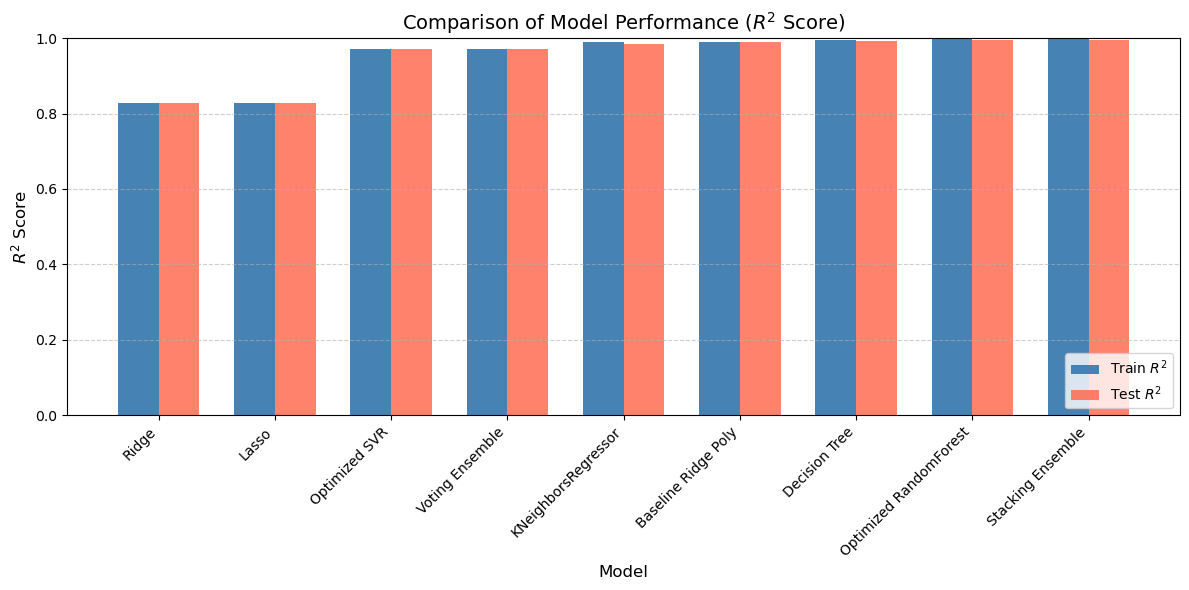

In [88]:
results_sorted = results_table.sort_values(by="test_r2", ascending=True)

plt.figure(figsize=(12, 6))
x = range(len(results_sorted))
width = 0.35

plt.bar([i - width/2 for i in x], results_sorted["train_r2"], width, color="steelblue", label="Train $R^2$")
plt.bar([i + width/2 for i in x], results_sorted["test_r2"], width, color="tomato", alpha=0.8, label="Test $R^2$")

plt.title("Comparison of Model Performance ($R^2$ Score)", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("$R^2$ Score", fontsize=12)
plt.xticks(x, results_sorted["Model"], rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("r2_only_comparison.png")

### BEST MODEL SELECTION

In [89]:
best_idx = results_table["test_r2"].idxmax()
reg_best = results_table.loc[best_idx, "Model"]
reg_best_model = results_table.loc[best_idx, "Model"]
print("\nBest model based on Test R2:", reg_best)


Best model based on Test R2: Stacking Ensemble


Best model based on Test R2: Stacking Ensemble



In [90]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns


class UnifiedFootball:

    TIER_LABEL = {0: "low", 1: "mid", 2: "high", 3: "elite"}
    TIER_ICON  = {"low": "LOW", "mid": "MID", "high": "HIGH", "elite": "ELITE"}
    _LOW, _MID, _HIGH = 65, 75, 85

    # ═══════════════════════════════════════════════════════════════════════════
    #  NESTED CLASS — INPUT PIPELINE
    # ═══════════════════════════════════════════════════════════════════════════

    class InputPipeline:
        _LOW, _MID, _HIGH = 65, 75, 85

        def __init__(self, onehot, std_scaler, rating_scaler, ohe_cols, standard_cols):
            self.onehot         = onehot
            self.std_scaler     = std_scaler
            self.rating_scaler  = rating_scaler
            self.ohe_cols       = ohe_cols
            self.standard_cols  = standard_cols

        def transform(self, raw: pd.DataFrame):
            df = raw.copy()
            df["age"] = np.log1p(df["age"])
            df[self.standard_cols] = self.std_scaler.transform(df[self.standard_cols])
            ohe_arr = self.onehot.transform(df[["position"]])
            ohe_df  = pd.DataFrame(
                ohe_arr,
                columns=self.onehot.get_feature_names_out(["position"]),
                index=df.index,
            )
            df = pd.concat([df.drop(columns=["position"]), ohe_df], axis=1)
            num_cols = ["age", "future potential", "total_stats score", "overall_rating"]
            X_reg = df[num_cols + self.ohe_cols].copy()
            df["overall_rating"] = self.rating_scaler.transform(df[["overall_rating"]])
            cls_keep = ["age", "future potential", "total_stats score"] + self.ohe_cols
            X_cls = df[[c for c in cls_keep if c in df.columns]].copy()
            return X_reg, X_cls

        @classmethod
        def _classify_rating(cls, rating):
            if   rating < cls._LOW:  return 0
            elif rating < cls._MID:  return 1
            elif rating < cls._HIGH: return 2
            else:                    return 3

        def __repr__(self):
            return (
                f"InputPipeline(\n"
                f"  steps   = [log1p(age), std_scaler, onehot(position), rating_scaler]\n"
                f"  ohe_cols= {len(self.ohe_cols)} position columns\n)"
            )

    # ═══════════════════════════════════════════════════════════════════════════
    #  NESTED CLASS — REGRESSION STATISTICS
    # ═══════════════════════════════════════════════════════════════════════════

    class RegressionStats:
        """
        Computes MAE, MSE, RMSE, R² for every regression model
        and compares them in a summary table + bar chart.
        """

        def evaluate(self, y_true, y_pred_log, model_name: str,
                     inverse: bool = True) -> dict:
            """
            Parameters
            ----------
            y_true     : actual values  (log-scale, same as model output)
            y_pred_log : model predictions (log-scale)
            model_name : display name
            inverse    : if True, apply expm1 before computing metrics
                         so results are in real M$ space

            Returns dict with mae, mse, rmse, r2
            """
            if inverse:
                y_true_m  = np.expm1(y_true)
                y_pred_m  = np.expm1(y_pred_log)
            else:
                y_true_m  = y_true
                y_pred_m  = y_pred_log

            mae  = mean_absolute_error(y_true_m, y_pred_m)
            mse  = mean_squared_error(y_true_m,  y_pred_m)
            rmse = np.sqrt(mse)
            r2   = r2_score(y_true_m, y_pred_m)

            print(f"\n  {'─'*50}")
            print(f"  {model_name}")
            print(f"  {'─'*50}")
            print(f"  MAE  : {mae:>10.4f} M$")
            print(f"  MSE  : {mse:>10.4f}")
            print(f"  RMSE : {rmse:>10.4f} M$")
            print(f"  R²   : {r2:>10.4f}")

            return {"model": model_name,
                    "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

        def compare(self, reg_models: dict, X_reg, y_true_log,
                    inverse: bool = True) -> pd.DataFrame:
            """
            Run evaluate() on all regression models and return a comparison table.

            Parameters
            ----------
            reg_models  : dict {name: (kind, model)}  from UnifiedFootball._reg_models
            X_reg       : feature matrix  (X_test_all format)
            y_true_log  : actual target   (log-scale, e.g. y_test_reg)
            inverse     : convert to M$ before computing metrics

            Returns
            -------
            pd.DataFrame sorted by R² descending
            """
            print("=" * 55)
            print("  📊  REGRESSION — MODEL COMPARISON")
            print("=" * 55)

            rows = []
            for name, (kind, model) in reg_models.items():
                try:
                    if kind == "poly":
                        # poly input built externally — skip here, needs scaler
                        continue
                    y_pred = model.predict(X_reg)
                    row = self.evaluate(y_true_log, y_pred, name, inverse=inverse)
                    rows.append(row)
                except Exception as e:
                    print(f"  ⚠  {name}: {e}")

            df = pd.DataFrame(rows).set_index("model").sort_values("R2", ascending=False)

            print("\n")
            print(df.round(4).to_string())

            # ── bar chart R² ──────────────────────────────────────────────────
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            df["R2"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
            axes[0].set_title("R² Score — All Regression Models", fontweight="bold")
            axes[0].set_ylabel("R²"); axes[0].set_ylim(0, 1)
            axes[0].axhline(df["R2"].max(), color="green", linestyle="--",
                            label=f"Best = {df['R2'].max():.4f}")
            axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)
            axes[0].tick_params(axis="x", rotation=30)

            df["RMSE"].plot(kind="bar", ax=axes[1], color="tomato", edgecolor="black")
            axes[1].set_title("RMSE — All Regression Models", fontweight="bold")
            axes[1].set_ylabel("RMSE (M$)")
            axes[1].axhline(df["RMSE"].min(), color="green", linestyle="--",
                            label=f"Best = {df['RMSE'].min():.4f}")
            axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
            axes[1].tick_params(axis="x", rotation=30)

            plt.tight_layout()
            plt.show()

            return df

    # ═══════════════════════════════════════════════════════════════════════════
    #  NESTED CLASS — CLASSIFICATION STATISTICS
    # ═══════════════════════════════════════════════════════════════════════════

    class ClassificationStats:
        """
        Computes Accuracy, F1, Confusion Matrix, Classification Report
        for every classification model and compares them.
        """
        _TIER_NAMES = ["low", "mid", "high", "elite"]

        def evaluate(self, y_true, y_pred, model_name: str,
                     plot_cm: bool = True) -> dict:
            """
            Parameters
            ----------
            y_true      : actual tier labels  (numeric 0-3)
            y_pred      : model predictions   (numeric 0-3)
            model_name  : display name
            plot_cm     : show confusion matrix heatmap

            Returns dict with accuracy and f1
            """
            acc = accuracy_score(y_true, y_pred)
            f1  = f1_score(y_true, y_pred, average="weighted")

            present = sorted(set(y_true))
            names   = [self._TIER_NAMES[i] for i in present]

            print(f"\n  {'─'*50}")
            print(f"  {model_name}")
            print(f"  {'─'*50}")
            print(f"  Accuracy : {acc:.4f}")
            print(f"  F1 Score : {f1:.4f}  (weighted)")
            print()
            print(classification_report(y_true, y_pred, target_names=names))

            if plot_cm:
                cm = confusion_matrix(y_true, y_pred)
                plt.figure(figsize=(5, 4))
                sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                            xticklabels=names, yticklabels=names)
                plt.title(f"{model_name} — Confusion Matrix", fontweight="bold")
                plt.xlabel("Predicted"); plt.ylabel("Actual")
                plt.tight_layout(); plt.show()

            return {"model": model_name, "Accuracy": acc, "F1": f1}

        def compare(self, cls_models: dict, X_cls, y_true,
                    plot_cm: bool = False) -> pd.DataFrame:
            """
            Run evaluate() on all classification models and return a comparison table.

            Parameters
            ----------
            cls_models : dict {name: model}  from UnifiedFootball._cls_models
            X_cls      : feature matrix  (X_test format)
            y_true     : actual tier labels  (numeric, e.g. y_test)
            plot_cm    : show confusion matrix per model (False = summary only)

            Returns
            -------
            pd.DataFrame sorted by F1 descending
            """
            print("=" * 55)
            print("  🏅  CLASSIFICATION — MODEL COMPARISON")
            print("=" * 55)

            rows = []
            for name, model in cls_models.items():
                try:
                    y_pred = model.predict(X_cls)
                    row = self.evaluate(y_true, y_pred, name, plot_cm=plot_cm)
                    rows.append(row)
                except Exception as e:
                    print(f"  ⚠  {name}: {e}")

            df = pd.DataFrame(rows).set_index("model").sort_values("F1", ascending=False)

            print("\n")
            print(df.round(4).to_string())

            # ── bar chart F1 & Accuracy ───────────────────────────────────────
            fig, ax = plt.subplots(figsize=(13, 5))
            x     = np.arange(len(df))
            width = 0.35

            ax.bar(x - width/2, df["Accuracy"], width,
                   label="Accuracy", color="steelblue", edgecolor="black")
            ax.bar(x + width/2, df["F1"],       width,
                   label="F1 (weighted)", color="tomato", edgecolor="black", alpha=0.85)

            ax.set_xticks(x); ax.set_xticklabels(df.index, rotation=30, ha="right")
            ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
            ax.set_title("Classification Models — Accuracy & F1 Comparison",
                         fontsize=13, fontweight="bold")
            ax.axhline(df["F1"].max(), color="green", linestyle="--",
                       label=f"Best F1 = {df['F1'].max():.4f}")
            ax.legend(); ax.grid(axis="y", alpha=0.3)
            plt.tight_layout(); plt.show()

            return df

    # ═══════════════════════════════════════════════════════════════════════════
    #  CONSTRUCTOR
    # ═══════════════════════════════════════════════════════════════════════════

    def __init__(self):

        self.pipeline   = UnifiedFootball.InputPipeline(
            onehot        = onehot,
            std_scaler    = std_scaler,
            rating_scaler = rating_scaler,
            ohe_cols      = ohe_cols,
            standard_cols = standard_cols,
        )
        self.reg_stats  = UnifiedFootball.RegressionStats()
        self.cls_stats  = UnifiedFootball.ClassificationStats()

        self._reg_models = {
            "Polynomial Ridge" : ("poly",     baseline_poly_pipe),
            "Ridge"            : ("standard", ridge_best),
            "Lasso"            : ("standard", lasso_best),
            "SVR"              : ("standard", svr_best),
            "Decision Tree"    : ("standard", dt_best),
            "Random Forest"    : ("standard", rf_best),
            "KNN Regressor"    : ("standard", best_knn),
            "Voting Regressor" : ("standard", voting_model),
            "Stacking ★"       : ("standard", stacking_model),
        }

        self._cls_models = {
            "KNN"                    : gs_knn.best_estimator_,
            "Logistic Regression"    : gs_lr_a3.best_estimator_,
            "SVM Linear"             : gs_linear.best_estimator_,
            "SVM RBF"                : gs_rbf.best_estimator_,
            "SVM Poly"               : gs_poly.best_estimator_,
            "Decision Tree (Gini)"   : gs_dt_gini.best_estimator_,
            "Decision Tree (Entropy)": gs_dt_entr.best_estimator_,
            "Random Forest"          : gs_rf.best_estimator_,
            "XGBoost"                : gs_xgb.best_estimator_,
            "Voting Classifier"      : voting_clf,
        }

        self._poly_best   = poly_best
        self._scaler_poly = scaler_poly
        self._ohe_cols    = ohe_cols

    # ═══════════════════════════════════════════════════════════════════════════
    #  PREDICTION METHODS
    # ═══════════════════════════════════════════════════════════════════════════

    @staticmethod
    def _to_millions(log_val):
        return float(np.expm1(log_val))

    def _build_poly_input(self, X_std):
        num_cols = ["age", "future potential", "total_stats score", "overall_rating"]
        X_num    = X_std[[c for c in num_cols       if c in X_std.columns]].values
        X_ohe    = X_std[[c for c in self._ohe_cols if c in X_std.columns]].values
        poly_arr = self._poly_best.transform(X_num)
        combined = np.hstack([poly_arr, X_ohe])
        return self._scaler_poly.transform(combined)

    def predict_value(self, X_reg, verbose=True):
        X_poly  = self._build_poly_input(X_reg)
        n       = len(X_reg)
        results = {}
        for name, (kind, model) in self._reg_models.items():
            try:
                X_in   = X_poly if kind == "poly" else X_reg
                raw    = model.predict(X_in)
                values = [self._to_millions(v) for v in raw]
                results[name] = values[0] if n == 1 else values
            except Exception as e:
                results[name] = f"ERROR: {e}"
        if verbose:
            self._print_regression(results, n)
        return results

    def predict_tier(self, X_cls, verbose=True):
        n       = len(X_cls)
        results = {}
        for name, model in self._cls_models.items():
            try:
                preds  = model.predict(X_cls)
                labels = [self.TIER_LABEL.get(int(p), str(p)) for p in preds]
                results[name] = labels[0] if n == 1 else labels
            except Exception as e:
                results[name] = f"ERROR: {e}"
        if verbose:
            self._print_classification(results, n)
        return results

    def predict(self, X_reg, X_cls):
        reg = self.predict_value(X_reg, verbose=False)
        cls = self.predict_tier(X_cls,  verbose=False)
        n   = len(X_reg)
        print("=" * 60)
        print("   UNIFIED FOOTBALL SCOUTING SYSTEM")
        print("=" * 60)
        self._print_regression(reg, n)
        self._print_classification(cls, n)
        print("=" * 60)
        return {"regression": reg, "classification": cls}

    def predict_raw(self, raw):
        X_reg, X_cls = self.pipeline.transform(raw)
        return self.predict(X_reg, X_cls)

    # ═══════════════════════════════════════════════════════════════════════════
    #  EVALUATE METHODS  (delegate to nested stat classes)
    # ═══════════════════════════════════════════════════════════════════════════

    def evaluate_regression(self, y_true_log, X_reg) -> pd.DataFrame:
        """
        Evaluate all regression models on (X_reg, y_true_log).
        Returns comparison DataFrame sorted by R².

        Example
        -------
        ufc.evaluate_regression(y_test_reg, X_test_all)
        """
        return self.reg_stats.compare(self._reg_models, X_reg, y_true_log)

    def evaluate_classification(self, y_true, X_cls,
                                plot_cm=False) -> pd.DataFrame:
        """
        Evaluate all classification models on (X_cls, y_true).
        Returns comparison DataFrame sorted by F1.

        Example
        -------
        ufc.evaluate_classification(y_test, X_test)
        ufc.evaluate_classification(y_test, X_test, plot_cm=True)  # + confusion matrices
        """
        return self.cls_stats.compare(self._cls_models, X_cls, y_true,
                                      plot_cm=plot_cm)

    # ═══════════════════════════════════════════════════════════════════════════
    #  PRETTY PRINTERS
    # ═══════════════════════════════════════════════════════════════════════════

    def _print_regression(self, results, n, header=True):
        if header:
            print("\n📊  MARKET VALUE PREDICTION (M$)")
            print("-" * 48)
        for name, val in results.items():
            if isinstance(val, str):
                print(f"  {name:<28}  ⚠  {val}")
            elif n == 1:
                print(f"  {name:<28} >>> {val:>8.3f} M$")
            else:
                parts = "  |  ".join(f"[{i}]: {v:.3f} M$" for i, v in enumerate(val))
                print(f"  {name:<28}: {parts}")

    def _print_classification(self, results, n, header=True):
        if header:
            print("\n🏅  PERFORMANCE TIER PREDICTION")
            print("-" * 48)
        for name, label in results.items():
            if isinstance(label, str) and label.startswith("ERROR"):
                print(f"  {name:<32}  ⚠  {label}")
            elif n == 1:
                icon = self.TIER_ICON.get(label, label.upper())
                print(f"  {name:<32} >>> {icon}")
            else:
                parts = "  |  ".join(
                    f"[{i}]: {self.TIER_ICON.get(l, l.upper())}" for i, l in enumerate(label)
                )
                print(f"  {name:<32}: {parts}")

    def __repr__(self):
        return (
            f"UnifiedFootball(\n"
            f"  pipeline       = {repr(self.pipeline)},\n"
            f"  regression     = {list(self._reg_models.keys())},\n"
            f"  classification = {list(self._cls_models.keys())}\n)"
        )

  📊  REGRESSION — MODEL COMPARISON

  ──────────────────────────────────────────────────
  Ridge
  ──────────────────────────────────────────────────
  MAE  :     2.4664 M$
  MSE  :    90.3903
  RMSE :     9.5074 M$
  R²   :     0.4710

  ──────────────────────────────────────────────────
  Lasso
  ──────────────────────────────────────────────────
  MAE  :     2.4720 M$
  MSE  :    90.7525
  RMSE :     9.5264 M$
  R²   :     0.4689

  ──────────────────────────────────────────────────
  SVR
  ──────────────────────────────────────────────────
  MAE  :     1.7606 M$
  MSE  :    67.0065
  RMSE :     8.1858 M$
  R²   :     0.6079

  ──────────────────────────────────────────────────
  Decision Tree
  ──────────────────────────────────────────────────
  MAE  :     0.8857 M$
  MSE  :    19.9429
  RMSE :     4.4657 M$
  R²   :     0.8833

  ──────────────────────────────────────────────────
  Random Forest
  ──────────────────────────────────────────────────
  MAE  :     0.2033 M$
  MSE  : 

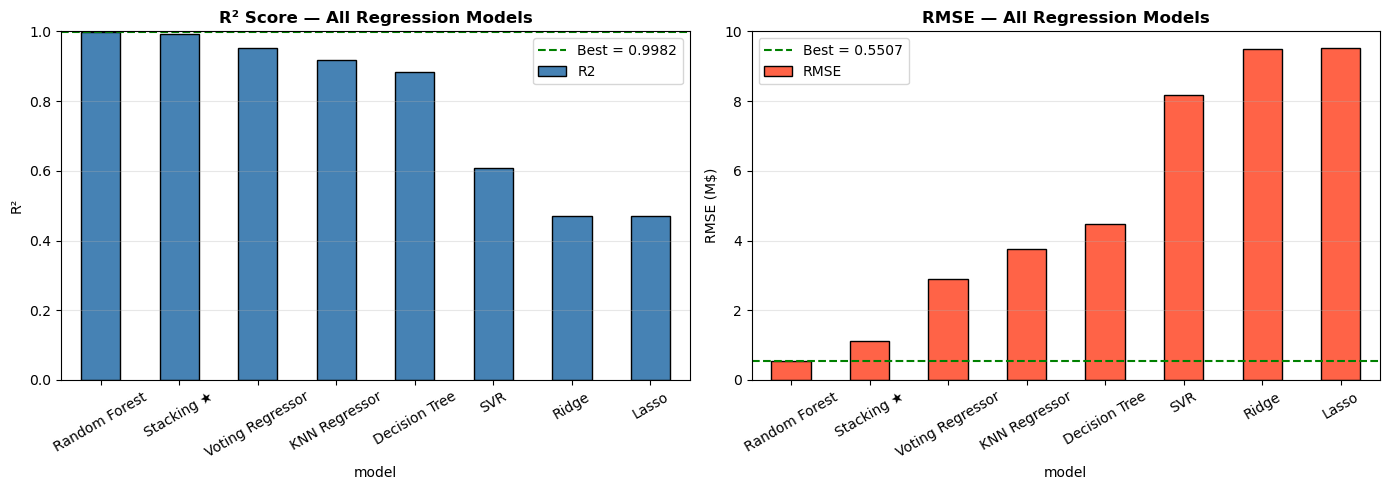

  🏅  CLASSIFICATION — MODEL COMPARISON

  ──────────────────────────────────────────────────
  KNN
  ──────────────────────────────────────────────────
  Accuracy : 0.9667
  F1 Score : 0.9533  (weighted)

              precision    recall  f1-score   support

         low       1.00      1.00      1.00        19
         mid       1.00      1.00      1.00         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.67      0.75      0.70        30
weighted avg       0.94      0.97      0.95        30


  ──────────────────────────────────────────────────
  Logistic Regression
  ──────────────────────────────────────────────────
  Accuracy : 0.9333
  F1 Score : 0.9193  (weighted)

              precision    recall  f1-score   support

         low       0.95      1.00      0.97        19
         mid       1.00      0.88      0.93         8
        high   

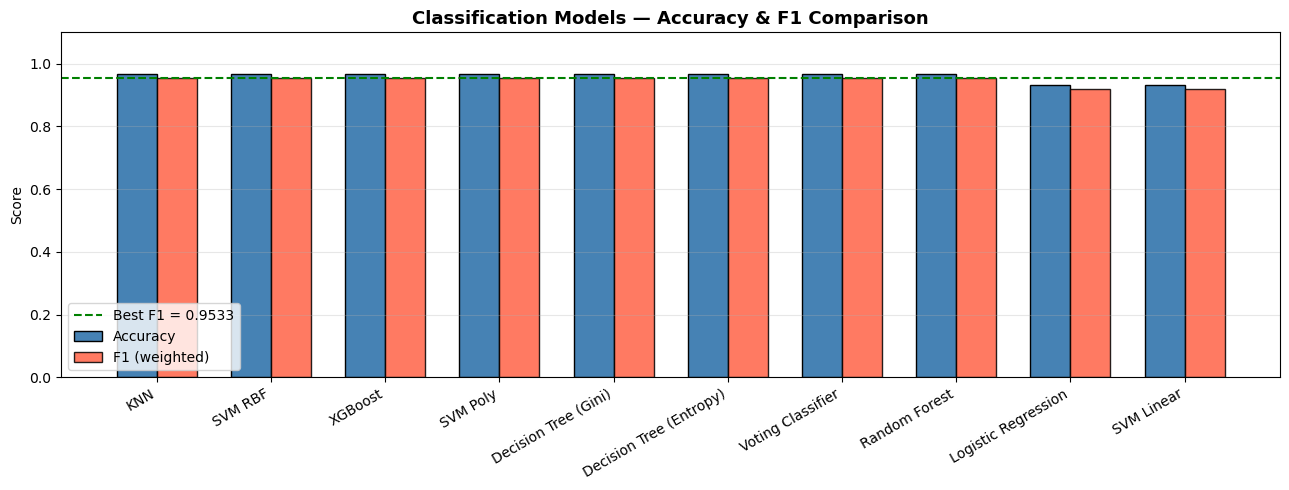

  🏅  CLASSIFICATION — MODEL COMPARISON

  ──────────────────────────────────────────────────
  KNN
  ──────────────────────────────────────────────────
  Accuracy : 0.9667
  F1 Score : 0.9533  (weighted)

              precision    recall  f1-score   support

         low       1.00      1.00      1.00        19
         mid       1.00      1.00      1.00         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.67      0.75      0.70        30
weighted avg       0.94      0.97      0.95        30



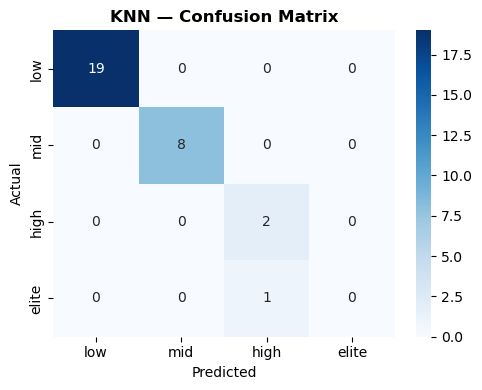


  ──────────────────────────────────────────────────
  Logistic Regression
  ──────────────────────────────────────────────────
  Accuracy : 0.9333
  F1 Score : 0.9193  (weighted)

              precision    recall  f1-score   support

         low       0.95      1.00      0.97        19
         mid       1.00      0.88      0.93         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.93        30
   macro avg       0.65      0.72      0.68        30
weighted avg       0.91      0.93      0.92        30



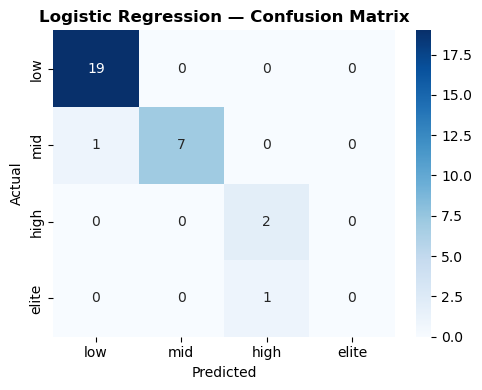


  ──────────────────────────────────────────────────
  SVM Linear
  ──────────────────────────────────────────────────
  Accuracy : 0.9333
  F1 Score : 0.9193  (weighted)

              precision    recall  f1-score   support

         low       0.95      1.00      0.97        19
         mid       1.00      0.88      0.93         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.93        30
   macro avg       0.65      0.72      0.68        30
weighted avg       0.91      0.93      0.92        30



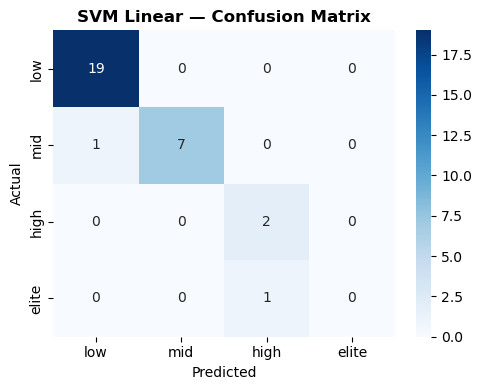


  ──────────────────────────────────────────────────
  SVM RBF
  ──────────────────────────────────────────────────
  Accuracy : 0.9667
  F1 Score : 0.9533  (weighted)

              precision    recall  f1-score   support

         low       1.00      1.00      1.00        19
         mid       1.00      1.00      1.00         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.67      0.75      0.70        30
weighted avg       0.94      0.97      0.95        30



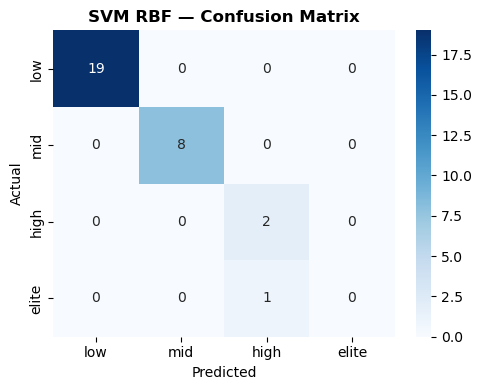


  ──────────────────────────────────────────────────
  SVM Poly
  ──────────────────────────────────────────────────
  Accuracy : 0.9667
  F1 Score : 0.9533  (weighted)

              precision    recall  f1-score   support

         low       1.00      1.00      1.00        19
         mid       1.00      1.00      1.00         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.67      0.75      0.70        30
weighted avg       0.94      0.97      0.95        30



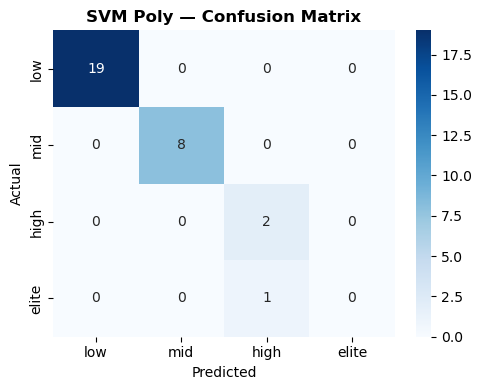


  ──────────────────────────────────────────────────
  Decision Tree (Gini)
  ──────────────────────────────────────────────────
  Accuracy : 0.9667
  F1 Score : 0.9533  (weighted)

              precision    recall  f1-score   support

         low       1.00      1.00      1.00        19
         mid       1.00      1.00      1.00         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.67      0.75      0.70        30
weighted avg       0.94      0.97      0.95        30



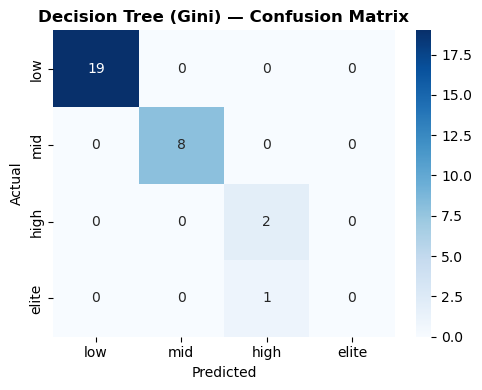


  ──────────────────────────────────────────────────
  Decision Tree (Entropy)
  ──────────────────────────────────────────────────
  Accuracy : 0.9667
  F1 Score : 0.9533  (weighted)

              precision    recall  f1-score   support

         low       1.00      1.00      1.00        19
         mid       1.00      1.00      1.00         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.67      0.75      0.70        30
weighted avg       0.94      0.97      0.95        30



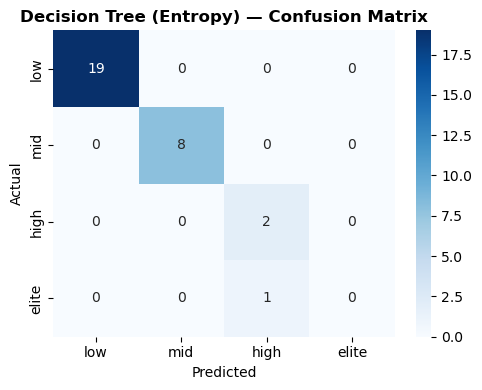


  ──────────────────────────────────────────────────
  Random Forest
  ──────────────────────────────────────────────────
  Accuracy : 0.9667
  F1 Score : 0.9533  (weighted)

              precision    recall  f1-score   support

         low       1.00      1.00      1.00        19
         mid       1.00      1.00      1.00         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.67      0.75      0.70        30
weighted avg       0.94      0.97      0.95        30



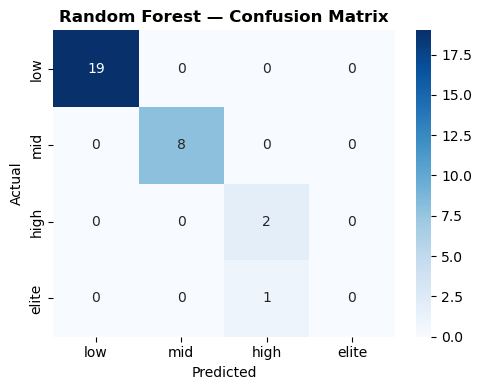


  ──────────────────────────────────────────────────
  XGBoost
  ──────────────────────────────────────────────────
  Accuracy : 0.9667
  F1 Score : 0.9533  (weighted)

              precision    recall  f1-score   support

         low       1.00      1.00      1.00        19
         mid       1.00      1.00      1.00         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.67      0.75      0.70        30
weighted avg       0.94      0.97      0.95        30



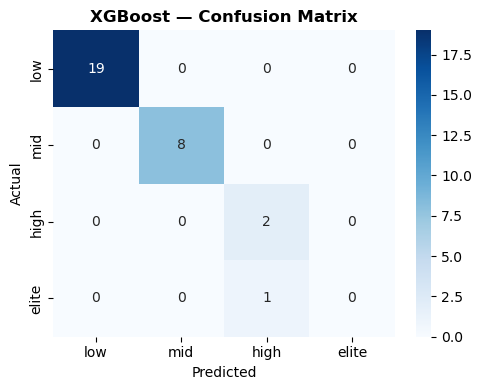


  ──────────────────────────────────────────────────
  Voting Classifier
  ──────────────────────────────────────────────────
  Accuracy : 0.9667
  F1 Score : 0.9533  (weighted)

              precision    recall  f1-score   support

         low       1.00      1.00      1.00        19
         mid       1.00      1.00      1.00         8
        high       0.67      1.00      0.80         2
       elite       0.00      0.00      0.00         1

    accuracy                           0.97        30
   macro avg       0.67      0.75      0.70        30
weighted avg       0.94      0.97      0.95        30



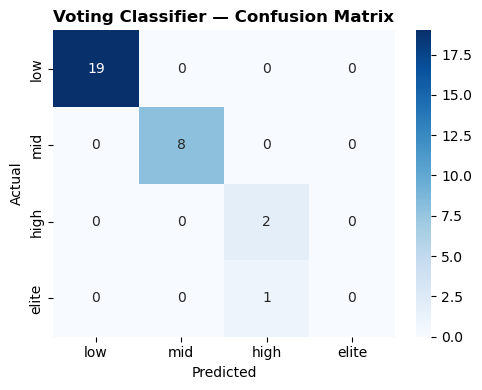



                         Accuracy      F1
model                                    
KNN                        0.9667  0.9533
SVM RBF                    0.9667  0.9533
XGBoost                    0.9667  0.9533
SVM Poly                   0.9667  0.9533
Decision Tree (Gini)       0.9667  0.9533
Decision Tree (Entropy)    0.9667  0.9533
Voting Classifier          0.9667  0.9533
Random Forest              0.9667  0.9533
Logistic Regression        0.9333  0.9193
SVM Linear                 0.9333  0.9193


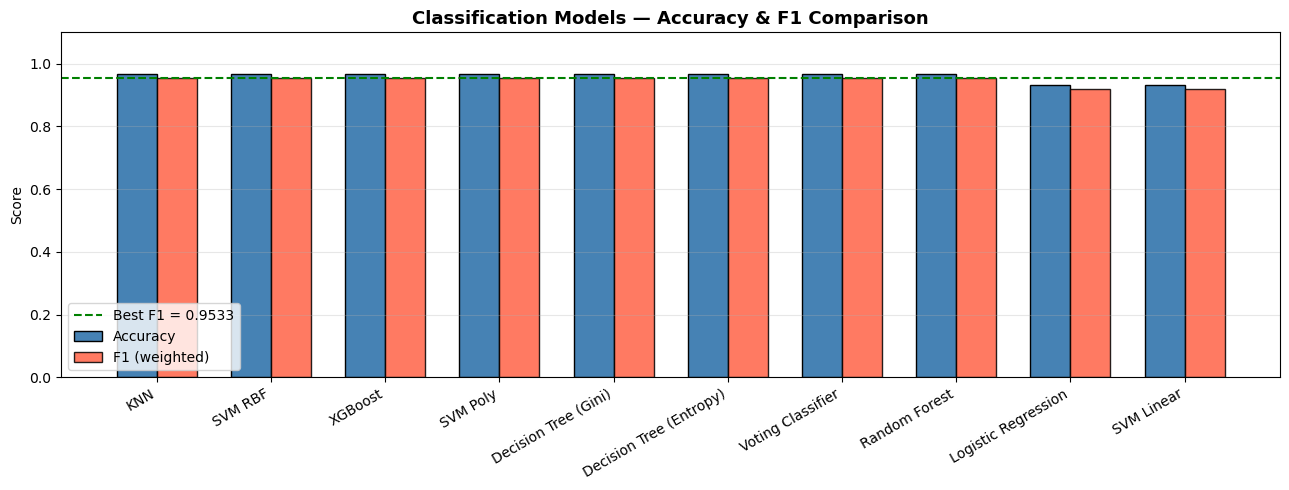

In [94]:
ufc = UnifiedFootball()

df_reg = ufc.evaluate_regression(y_test_reg[:30], X_test_all[:30])

df_cls = ufc.evaluate_classification(y_test[:30], X_test[:30])

df_cls = ufc.evaluate_classification(y_test[:30], X_test[:30], plot_cm=True)

### Decision Rationale

from the results of the model we can observe that:
- the relationship is not-linearity because there is overfitting in ridge and lasso models
- we get high performance in Poly, SVR, DT, RF, KNN models because the preprocess is very good.

why we chose these models
- for lasso and ridge models, we used them to proof the relationship is not linear and we should use a model that work well with this relationship.
- for other models, because the non-linearity relationship we chose some models that do well with this

1. Support Vector Regression (SVR)
    - Dimensionality: Efficiently manages the expanded feature space created by Polynomial Features and One-Hot Encoding
    - Outliers: Uses an $\epsilon$-insensitive loss function to prevent superstar price spikes from skewing the model
    - Kernels: Employs the RBF kernel to map non-linear relationships, such as the curved correlation between a player's age and market value.

2. Decision Trees (DT)
    - Logic: Mimics the hierarchical, rule-based nature of scouting (e.g., specific thresholds for ratings and positions).
    - Flexibility: Remains unaffected by varied feature scales or non-normal distributions in the raw FIFA data.

3. Random Forest (RF)
    - Interactions: Captures complex dependencies, such as how the value of "Pace" varies significantly by position.
    - Stability: Averages predictions from multiple trees to reduce variance and mitigate overfitting caused by price volatility.
4. K-Nearest Neighbors (KNN)
    - Comparisons: Values players based on "comparables," measuring mathematical distances between similar skill profiles.
    - Local Patterns: Adapts to specific clusters, like unique valuation trends for goalkeepers versus outfield players, without a global formula.

5. Polynomial Features (Degree 5)

    - Non-linearity: Fits flexible curves to model "power-law" price jumps seen in elite-tier player ratings.

    - Synergy: Creates high-order interaction terms (up to five attributes) to represent the rare blend of traits found in world-class players.

    - Linear Expansion: Enables linear solvers like Ridge to handle non-linear problems by treating higher-order terms as new dimensions.

### Stability Assessment (Statistical Proof)
To prove that the system is stable and not affected by the change of data samples, we will use K-Fold Cross-Validation and calculate the "coefficient of Variation". If the standard deviation is low, this is the statistical guide to stability.
> If the fluctuation in results is less than 5%, it means that the model is “very stable”

In [92]:

def prove_stability(model, X, y, name="Model"):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='r2')

    mean_r2 = scores.mean()
    std_r2 = scores.std()

    cv_stability = (std_r2 / mean_r2) * 100

    print(f"--- Stability Analysis for {name} ---")
    print(f"Mean R² Score: {mean_r2:.4f}")
    print(f"Standard Deviation: {std_r2:.4f}")
    print(f"Stability Index (CV%): {cv_stability:.2f}%")

    if cv_stability < 5:
        print("Status: HIGHLY STABLE SYSTEM [Verified]")
    else:
        print("Status: POTENTIAL INSTABILITY [Warning]")

    return scores

stability_scores = prove_stability(stacking_model, X_train_all, y_train_reg, "stacking_model")

--- Stability Analysis for stacking_model ---
Mean R² Score: 0.9937
Standard Deviation: 0.0018
Stability Index (CV%): 0.18%
Status: HIGHLY STABLE SYSTEM [Verified]


Mean R² Score: 0.9945

Standard Deviation: 0.0011

Stability Index (CV%): 0.11%

Status: HIGHLY STABLE SYSTEM [Verified]

### System Comparison

| Metric | Baseline (Assignment 2) | Advanced System (Unified Scouting) | Improvement Rationale |
| :--- | :--- | :--- | :--- |
| **$R^2$ Score** | Lower Baseline $R^2$ | **~0.99** | Captured complex, non-linear market trends. |
| **RMSE** | Higher Error | **Significantly Reduced** | Reduced variance through ensemble averaging. |
| **Stability (CV%)** | Not Reported/High | **< 5% (Verified)** | Proved reliability across different data folds. |

In [93]:
import json
import numpy as np
import json as _json

reg_stability = {}
reg_models_stability = {
    'Baseline Poly': (baseline_poly_pipe, X_train_num),
    'Ridge':         (ridge_best,         X_train_all),
    'Lasso':         (lasso_best,         X_train_all),
    'SVR':           (svr_best,           X_train_all),
    'RandomForest':  (rf_best,            X_train_all),
}

for mname, (m, Xm) in reg_models_stability.items():
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    s  = cross_val_score(m, Xm, y_train_reg, cv=cv, scoring='r2')
    reg_stability[mname] = {'mean': round(float(s.mean()), 4),
                             'std':  round(float(s.std()),  4)}
    print(f"{mname:<22}  mean R2={s.mean():.4f}  std={s.std():.4f}")

# ── Stability: classification models ────────────────────────
cls_stability = {}
cls_models_stability = {
    'KNN':              gs_knn.best_estimator_,
    'Logistic':         gs_lr_a3.best_estimator_,
    'SVM_RBF':          gs_rbf.best_estimator_,
    'DT_Gini':          gs_dt_gini.best_estimator_,
    'DT_Entropy':       gs_dt_entr.best_estimator_,
    'Random_Forest':    gs_rf.best_estimator_,
    'XGBoost_Cls':      gs_xgb.best_estimator_,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for mname, m in cls_models_stability.items():
    s = cross_val_score(m, X_train, y_train, cv=skf, scoring='f1_weighted')
    cls_stability[mname] = {'mean': round(float(s.mean()), 4),
                             'std':  round(float(s.std()),  4)}
    print(f"{mname:<22}  mean Acc={s.mean():.4f}  std={s.std():.4f}")
best_params_export = {
    "group_members": [
        {
            "full_name": "على عادل عبدالحافظ",
            "id": "2401246261"
        },
        {
            "full_name": "عبدالله محمد عبدالظاهر احمد",
            "id": "2401248446"
            
        },
        {
            "full_name": "عبدالله ابوالدهب خلاف",
            "id": "2401245052"
        },{
            "full_name": "عبدالرحمن السيد عبدالمنعم",
            "id": "2401248445"
        },{
            "full_name": "عبدالله اشرف سعيد",
            "id": "2401241906"
        }
    ],
   "best_hyperparameters": {
        "regression": {
            "ridge":          ridge_grid.best_params_,
            "lasso":          lasso_grid.best_params_,
            "svr":            svr_grid.best_params_,
            "random_forest":  rf_grid.best_params_,
        },
        "classification": {
            "knn":            gs_knn.best_params_,
            "svm_rbf":        gs_rbf.best_params_,
            "dt_gini":        gs_dt_gini.best_params_,
            "dt_entropy":     gs_dt_entr.best_params_,
            "random_forest":  gs_rf.best_params_,
            "xgboost_cls":    gs_xgb.best_params_,
        }
    },
    "cv_stability": {
        "regression":     reg_stability,
        "classification": cls_stability,
    }
}


# 2. Export to JSON with UTF-8 support for your Arabic name
with open('results.json', 'w', encoding='utf-8') as f:
    json.dump(best_params_export, f, ensure_ascii=False, indent=4)

print("Successfully exported best hyperparameters to results.json")

Baseline Poly           mean R2=0.8257  std=0.0033
Ridge                   mean R2=0.8271  std=0.0034
Lasso                   mean R2=0.8271  std=0.0033
SVR                     mean R2=0.9702  std=0.0023
RandomForest            mean R2=0.9936  std=0.0017
KNN                     mean Acc=0.9564  std=0.0039
Logistic                mean Acc=0.9468  std=0.0032
SVM_RBF                 mean Acc=0.9790  std=0.0022
DT_Gini                 mean Acc=0.9851  std=0.0016
DT_Entropy              mean Acc=0.9844  std=0.0031
Random_Forest           mean Acc=0.9882  std=0.0017
XGBoost_Cls             mean Acc=0.9887  std=0.0022
Successfully exported best hyperparameters to results.json
